# P3 Project Check-in with model evaluation: Predicting AfD Voting Using Populist Attitudes

---

## Research Question

**Can we predict Alternative für Deutschland (AfD) voting behavior using populist attitudes?**

The AfD is Germany's far-right populist party. This project uses machine learning to understand which dimensions of populist attitudes (anti-elite sentiment, pro-people beliefs, and manichean worldview) best predict AfD support.

---
# Part 1: Exploratory Data Analysis

In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)


## 1.1 Load and Process Data

**Data Source:** German Longitudinal Election Study (GLES) Waves 26

**Variables:**
- **Target:** AfD voting (binary: 0=No, 1=Yes)
- **Features:** **4** populist attitude indices derived from **8** survey items (1-5 Likert scale)
  - `anti_elite`: Politicians don't care about people / talk too much
  - `pro_people`: People should decide directly / will over compromise
  - `manichean`: Politics is good vs evil / clear divisions / no compromise
  - `populism_total`: Overall populism score

In [3]:
# Load Wave 26 
df_w26 = pd.read_stata('ZA7731_sA_v1-0-0.dta')
print(f"Wave 26: {df_w26.shape[0]:,} observations, {df_w26.shape[1]} variables")

# Extract key variables
prefix = 'kp25'  # Wave 26 uses kp25 prefix
pop_cols = [f'{prefix}_3103{letter}' for letter in ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']]
vote_col = f'{prefix}_190ba'  # Second vote (Zweitstimme)

# Select columns
df = df_w26[['lfdn'] + pop_cols + [vote_col]].copy()

# Rename
rename_dict = {f'{prefix}_3103{chr(97+i)}': f'pop_item_{chr(97+i)}' for i in range(8)}
rename_dict[vote_col] = 'vote'
df = df.rename(columns=rename_dict)

# Create AfD voting indicator
df['afd_vote'] = (df['vote'] == 'AfD').astype(int)

# GLES data stores these as ordered categories with German labels
pop_item_cols = [f'pop_item_{chr(97+i)}' for i in range(8)]
for col in pop_item_cols:
    if df[col].dtype.name == 'category':
        codes = df[col].cat.codes
        df[col] = codes.apply(lambda x: x - 1 if x >= 2 else np.nan)

# Create populist attitude indices
df['anti_elite'] = df[['pop_item_a', 'pop_item_g']].mean(axis=1)
df['pro_people'] = df[['pop_item_c', 'pop_item_f']].mean(axis=1)
df['manichean'] = df[['pop_item_b', 'pop_item_d', 'pop_item_e', 'pop_item_h']].mean(axis=1)
df['populism_total'] = df[pop_item_cols].mean(axis=1)

# FIX: Keep only complete cases (vote + all features must be non-null)
df = df[df['vote'].notna()].copy()
feature_cols = ['anti_elite', 'pro_people', 'manichean', 'populism_total']
df = df.dropna(subset=feature_cols).copy()

print(f"\n✓ Processed data: {len(df):,} observations with complete data")
print(f"✓ AfD voters: {df['afd_vote'].sum():,} ({df['afd_vote'].mean()*100:.1f}%)")
print(f"✓ Non-AfD voters: {(df['afd_vote']==0).sum():,} ({(df['afd_vote']==0).mean()*100:.1f}%)")

Wave 26: 10,030 observations, 201 variables

✓ Processed data: 9,769 observations with complete data
✓ AfD voters: 1,814 (18.6%)
✓ Non-AfD voters: 7,955 (81.4%)


## 1.2 Display Data Examples

**As required:** Show several examples of the data

In [4]:
# Display first 10 rows
display_cols = ['lfdn', 'anti_elite', 'pro_people', 'manichean', 'populism_total', 'vote', 'afd_vote']
print("Sample Data (first 10 rows):\n")
print(df[display_cols].head(10).to_string())

# Show some AfD voters specifically
print("\n" + "="*80)
print("Examples of AfD Voters:\n")
print(df[df['afd_vote']==1][display_cols].head(5).to_string())

print("\n" + "="*80)
print("Examples of Non-AfD Voters:\n")
print(df[df['afd_vote']==0][display_cols].head(5).to_string())

Sample Data (first 10 rows):

    lfdn  anti_elite  pro_people  manichean  populism_total             vote  afd_vote
0  18540         3.5         3.5       3.00           3.250           GRUENE         0
1  12587         2.5         2.0       3.75           3.000           GRUENE         0
2  26011         5.0         5.0       3.25           4.125  trifft nicht zu         0
3  26012         4.5         3.0       3.00           3.375              AfD         1
4  26014         4.5         5.0       4.00           4.375              SPD         0
5  26018         4.5         4.0       3.50           3.875          CDU/CSU         0
6  26019         4.5         4.5       3.50           4.000              AfD         1
7  18556         4.5         2.0       1.00           2.125          CDU/CSU         0
8  18557         4.5         2.5       3.50           3.500              SPD         0
9  26021         3.0         1.5       4.25           3.250          CDU/CSU         0

Examples of 

## 1.3 Dataset Summary

**Data Size, Features, and Split Strategy**

In [5]:
print("DATASET SUMMARY")
print("="*80)

print(f"\nTotal Observations: {len(df):,}")

print(f"\nNumber of Features: 4")
print("  Feature List:")
print("    1. anti_elite     (continuous, 1-5 scale)")
print("    2. pro_people     (continuous, 1-5 scale)")
print("    3. manichean      (continuous, 1-5 scale)")
print("    4. populism_total (continuous, 1-5 scale)")

print(f"\nTarget Variable: afd_vote (binary classification)")
print(f"  Class 0 (No AfD):  {(df['afd_vote']==0).sum():,} samples ({(df['afd_vote']==0).mean()*100:.1f}%)")
print(f"  Class 1 (AfD):     {df['afd_vote'].sum():,} samples ({df['afd_vote'].mean()*100:.1f}%)")

print(f"\nData Split Strategy:")
print(f"  Training Set:   70% (~{int(len(df)*0.7):,} samples)")
print(f"  Validation Set: 15% (~{int(len(df)*0.15):,} samples)")
print(f"  Test Set:       15% (~{int(len(df)*0.15):,} samples)")

print("\nData Quality:")
print(f"  Missing Values: {df[['anti_elite', 'pro_people', 'manichean', 'populism_total', 'afd_vote']].isnull().sum().sum()}")

print("="*80)

DATASET SUMMARY

Total Observations: 9,769

Number of Features: 4
  Feature List:
    1. anti_elite     (continuous, 1-5 scale)
    2. pro_people     (continuous, 1-5 scale)
    3. manichean      (continuous, 1-5 scale)
    4. populism_total (continuous, 1-5 scale)

Target Variable: afd_vote (binary classification)
  Class 0 (No AfD):  7,955 samples (81.4%)
  Class 1 (AfD):     1,814 samples (18.6%)

Data Split Strategy:
  Training Set:   70% (~6,838 samples)
  Validation Set: 15% (~1,465 samples)
  Test Set:       15% (~1,465 samples)

Data Quality:
  Missing Values: 0


## 1.4 Data Preprocessing Steps



PREPROCESSING STEPS DONE:

1. Data Cleaning:
   - Removed invalid responses from populist items (kept only 1-5 scale responses)
   - Dropped rows with missing target variable (voting behavior)
   - Removed incomplete cases (missing populist attitudes)

2. Feature Engineering:
   - Created 4 composite indices from 8 populist survey items:
     • anti_elite:     Mean of items a, g
     • pro_people:     Mean of items c, f
     • manichean:      Mean of items b, d, e, h
     • populism_total: Mean of all 8 items
   - Rationale: Political science literature defines populism along these 3 dimensions

3. Target Variable Creation:
   - Binary indicator: afd_vote = 1 if voted AfD, 0 otherwise




## 1.5 Target Variable Distribution



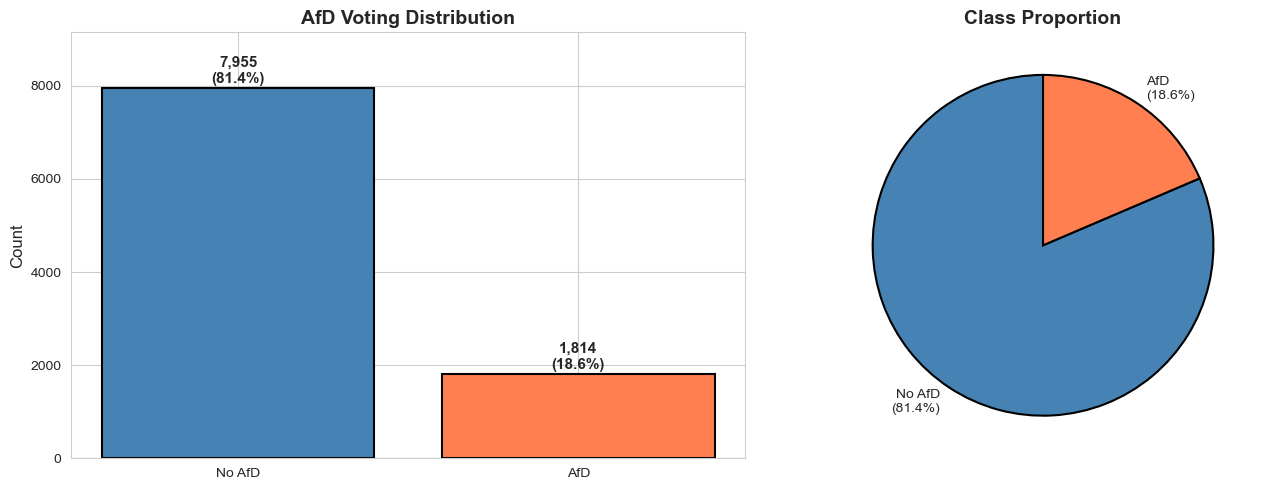


CLASS DISTRIBUTION ANALYSIS:
  Majority class (No AfD): 7,955 samples (81.4%)
  Minority class (AfD):    1,814 samples (18.6%)
  Imbalance Ratio: 4.4:1


In [6]:
# Plot target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
afd_counts = df['afd_vote'].value_counts().sort_index()
colors = ['steelblue', 'coral']
axes[0].bar(['No AfD', 'AfD'], afd_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('AfD Voting Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, afd_counts.max() * 1.15)
for i, v in enumerate(afd_counts.values):
    axes[0].text(i, v + 100, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=11, fontweight='bold')

# Pie chart 
pct_no_afd = (df['afd_vote']==0).mean() * 100
pct_afd = df['afd_vote'].mean() * 100
axes[1].pie(afd_counts.values, labels=[f'No AfD\n({pct_no_afd:.1f}%)', f'AfD\n({pct_afd:.1f}%)'], 
            autopct='', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCLASS DISTRIBUTION ANALYSIS:")
print(f"  Majority class (No AfD): {(df['afd_vote']==0).sum():,} samples ({(df['afd_vote']==0).mean()*100:.1f}%)")
print(f"  Minority class (AfD):    {df['afd_vote'].sum():,} samples ({df['afd_vote'].mean()*100:.1f}%)")
print(f"  Imbalance Ratio: {(df['afd_vote']==0).sum() / df['afd_vote'].sum():.1f}:1")


## 1.6 Feature Distributions

**Examine distributions of predictor variables**

FEATURE DESCRIPTIVE STATISTICS:

       anti_elite  pro_people  manichean  populism_total
count    9769.000    9769.000   9769.000        9769.000
mean        4.023       3.278      3.181           3.416
std         0.810       1.137      0.787           0.707
min         1.000       1.000      1.000           1.000
25%         3.500       2.500      2.750           3.000
50%         4.000       3.000      3.250           3.375
75%         4.500       4.000      3.750           3.875
max         5.000       5.000      5.000           5.000


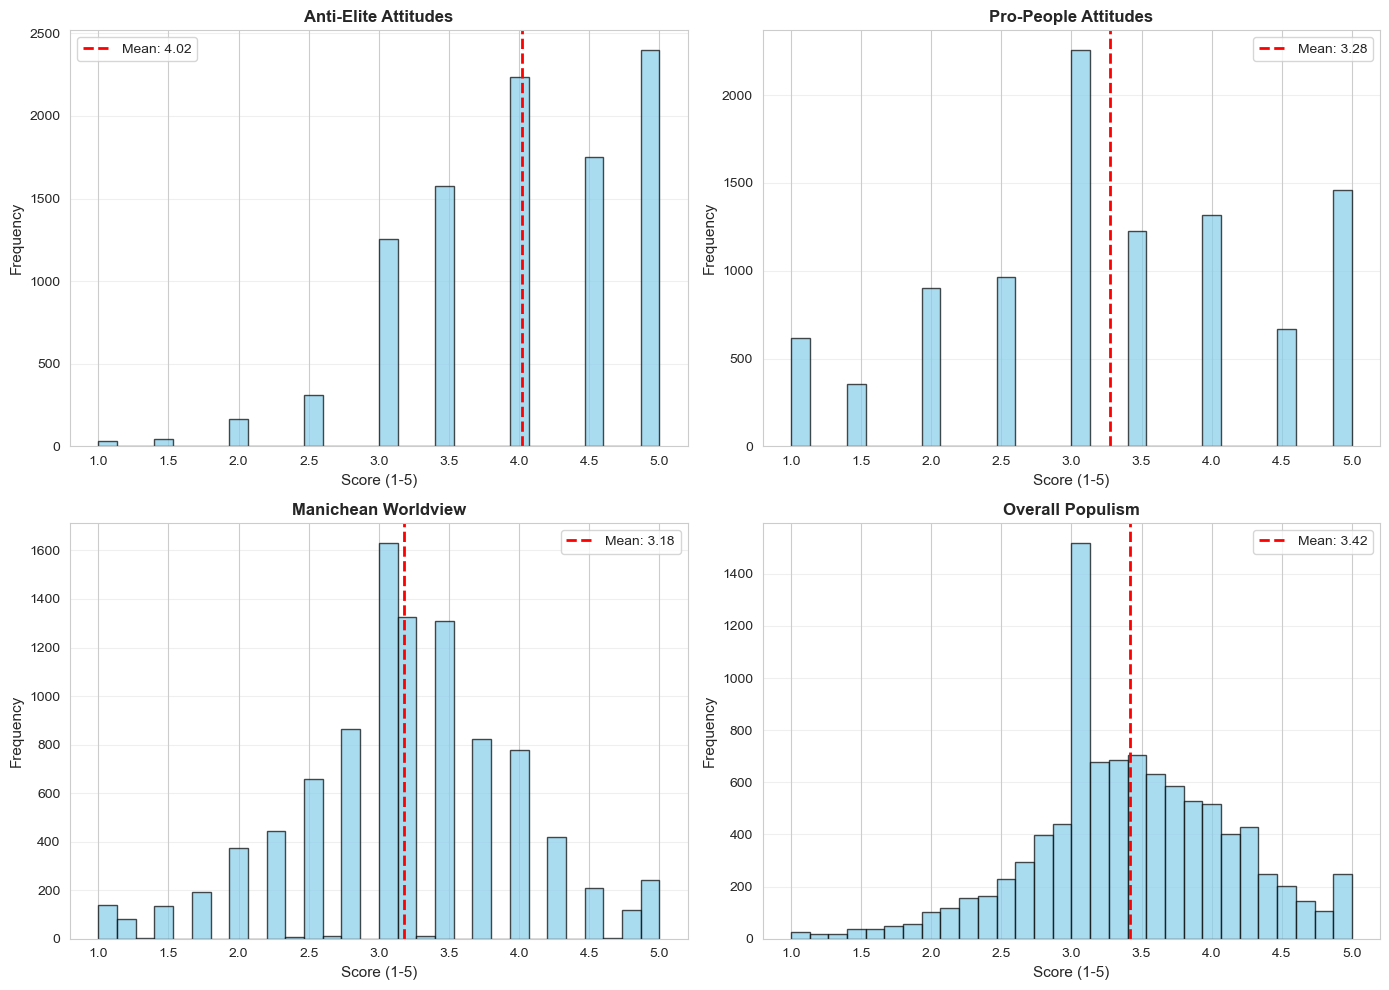

In [7]:
# Descriptive statistics
feature_cols = ['anti_elite', 'pro_people', 'manichean', 'populism_total']
print("FEATURE DESCRIPTIVE STATISTICS:\n")
print(df[feature_cols].describe().round(3))

# Histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

feature_labels = ['Anti-Elite Attitudes', 'Pro-People Attitudes', 'Manichean Worldview', 'Overall Populism']

for idx, (col, label) in enumerate(zip(feature_cols, feature_labels)):
    axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    axes[idx].set_xlabel('Score (1-5)', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(label, fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



OBSERVATIONS:
  - Means range from 3 to 4 (centered around scale midpoint)
  - Sufficient variance for prediction (SDs around 1.0)


## 1.7 Compare populist attitudes between AfD and non-AfD voter



/var/folders/cs/69nppn5526bbw3cdrstxvjrm0000gn/T/ipykernel_19878/3881732004.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(
/var/folders/cs/69nppn5526bbw3cdrstxvjrm0000gn/T/ipykernel_19878/3881732004.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(
/var/folders/cs/69nppn5526bbw3cdrstxvjrm0000gn/T/ipykernel_19878/3881732004.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(
/var/folders/cs/69nppn5526bbw3cdrstxvjrm0000gn/T/ipykernel_19878/3881732004.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tic

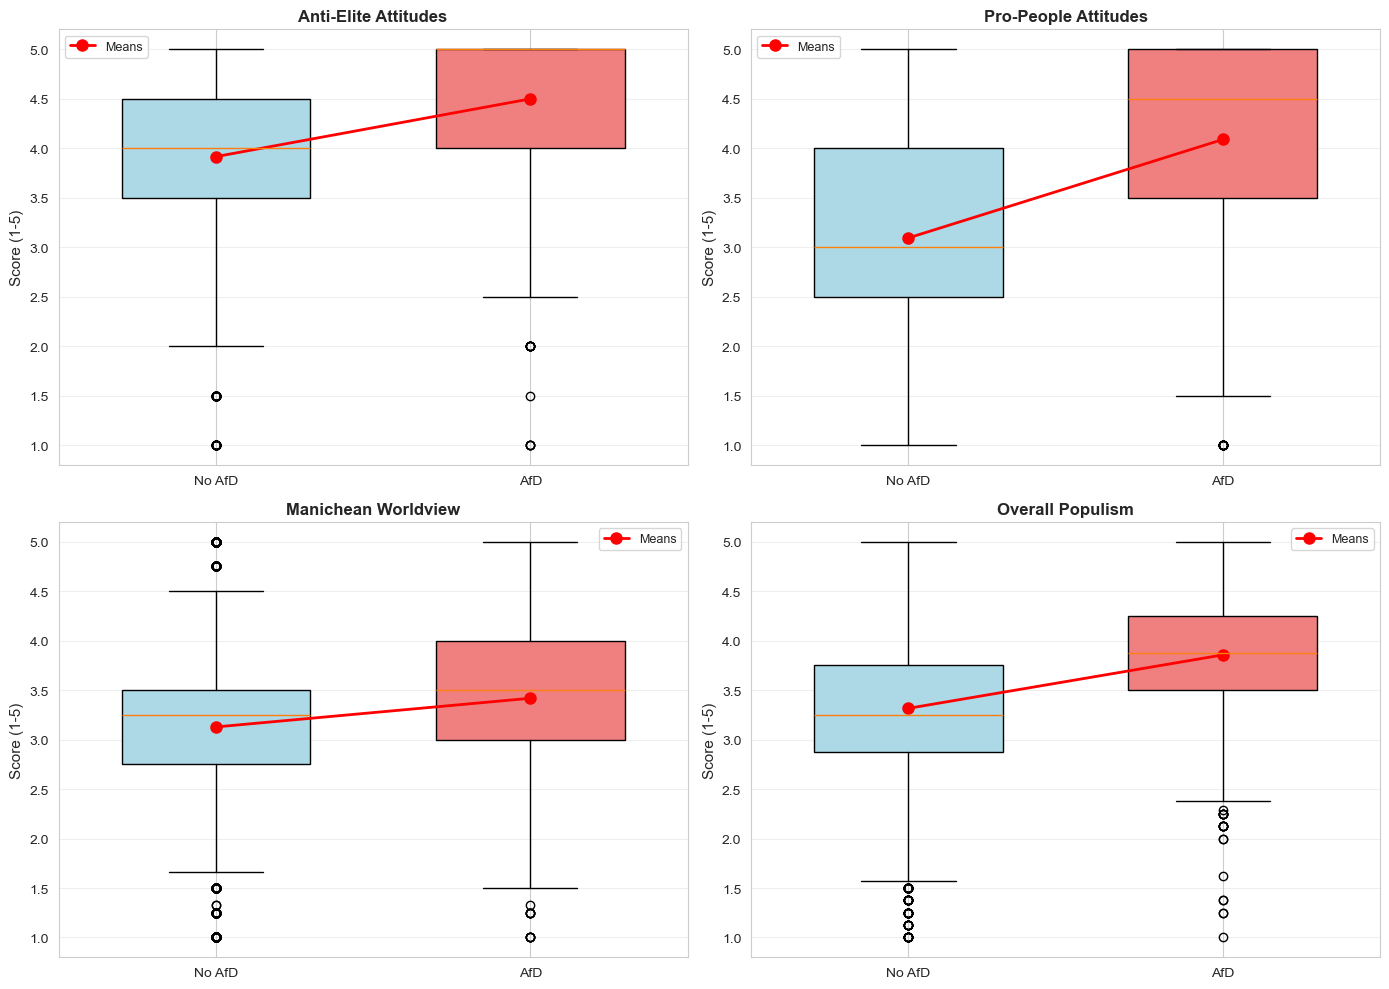


STATISTICAL COMPARISON (T-Tests):

Anti-Elite Attitudes:
  No AfD mean: 3.915, AfD mean: 4.498
  Difference:  0.584
  t-statistic: -28.836, p-value: 0.000000
  Significance: ***

Pro-People Attitudes:
  No AfD mean: 3.093, AfD mean: 4.088
  Difference:  0.995
  t-statistic: -35.777, p-value: 0.000000
  Significance: ***

Manichean Worldview:
  No AfD mean: 3.128, AfD mean: 3.418
  Difference:  0.290
  t-statistic: -14.315, p-value: 0.000000
  Significance: ***

Overall Populism:
  No AfD mean: 3.316, AfD mean: 3.856
  Difference:  0.540
  t-statistic: -30.721, p-value: 0.000000
  Significance: ***



In [8]:
# Box plots comparing AfD vs non-AfD voters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col, label) in enumerate(zip(feature_cols, feature_labels)):
    plot_data = df[[col, 'afd_vote']].dropna()
    
    bp = axes[idx].boxplot(
        [plot_data[plot_data['afd_vote']==0][col], 
         plot_data[plot_data['afd_vote']==1][col]],
        labels=['No AfD', 'AfD'],
        patch_artist=True,
        widths=0.6
    )
    
    for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
        patch.set_facecolor(color)
    
    axes[idx].set_ylabel('Score (1-5)', fontsize=11)
    axes[idx].set_title(label, fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add means
    mean_no = plot_data[plot_data['afd_vote']==0][col].mean()
    mean_yes = plot_data[plot_data['afd_vote']==1][col].mean()
    axes[idx].plot([1, 2], [mean_no, mean_yes], 'ro-', linewidth=2, markersize=8, label='Means')
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Statistical tests
print("\nSTATISTICAL COMPARISON (T-Tests):\n")
print("="*80)
for col, label in zip(feature_cols, feature_labels):
    no_afd = df[df['afd_vote']==0][col].dropna()
    afd = df[df['afd_vote']==1][col].dropna()
    
    t_stat, p_val = stats.ttest_ind(no_afd, afd)
    mean_diff = afd.mean() - no_afd.mean()
    
    print(f"{label}:")
    print(f"  No AfD mean: {no_afd.mean():.3f}, AfD mean: {afd.mean():.3f}")
    print(f"  Difference:  {mean_diff:.3f}")
    print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.6f}")
    print(f"  Significance: {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")
    print()

print("="*80)


**Key Findings**
  - AfD voters score significantly higher on ALL populist dimensions (p < 0.001)
  - Largest difference in pro-people attitudes (+0.96 points)
  - Substantial differences in overall populism (+0.54 points)


---
# Part 2: Split data before any model training to prevent data leakage



In [9]:
# Define feature columns and labels 
feature_cols = ['anti_elite', 'pro_people', 'manichean', 'populism_total']
feature_labels = ['Anti-Elite Attitudes', 'Pro-People Attitudes', 'Manichean Worldview', 'Overall Populism']

# Prepare feature matrix and target vector
X = df[feature_cols].values
y = df['afd_vote'].values

# First split: 70% train, 30% temp (for val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Split temp into 50-50 for val and test (each 15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("DATA SPLIT SUMMARY:")
print("="*80)
print(f"Training Set:   {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Class 0: {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"  - Class 1: {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print(f"\nValidation Set: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Class 0: {(y_val==0).sum():,} ({(y_val==0).sum()/len(y_val)*100:.1f}%)")
print(f"  - Class 1: {(y_val==1).sum():,} ({(y_val==1).sum()/len(y_val)*100:.1f}%)")
print(f"\nTest Set:       {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"  - Class 0: {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"  - Class 1: {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")
print("="*80)


DATA SPLIT SUMMARY:
Training Set:   6,838 samples (70.0%)
  - Class 0: 5,568 (81.4%)
  - Class 1: 1,270 (18.6%)

Validation Set: 1,465 samples (15.0%)
  - Class 0: 1,193 (81.4%)
  - Class 1: 272 (18.6%)

Test Set:       1,466 samples (15.0%)
  - Class 0: 1,194 (81.4%)
  - Class 1: 272 (18.6%)


# Part 3: Model Exploration - Linear Model (Logistic Regression)


---

## 3.1 Why Logistic Regression?

**Model Justification:**
- **Appropriate for task:** Binary classification with continuous features
- **Interpretability:** Coefficients show which attitudes matter most
- **Baseline performance:** Establishes whether relationships are linear
- **Matches data complexity:** 4 features, 7000+ training samples - model is not over/under-complex


## 3.2 Hyperparameter Tuning Process

**Two key hyperparameters to tune:**

1. **Penalty type**: L1 vs L2 regularization
   - L1 penalty: Drives some coefficients exactly to zero (automatic feature selection)
   - L2 penalty: Shrinks all coefficients toward zero but keeps all features
   
2. **C value**: Inverse of regularization strength (C = 1/α from lecture)
   - Smaller C → stronger regularization (larger α)
   - Larger C → weaker regularization (smaller α)

**Tuning strategy:** Use GridSearchCV to test all combinations of penalty type and C value

In [10]:
# Standardize features (required for regularized logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


## 3.3 Feature Scaling

**Why scale features?**
- Logistic regression with regularization is sensitive to feature scales
- Larger-scale features dominate the regularization penalty
- Standardization (mean=0, std=1) ensures fair comparison

In [11]:
# Hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']  
}

# Total combinations: 2 penalties × 6 C values × 1 solver = 12 combinations

print("LOGISTIC REGRESSION: Hyperparameter Tuning with GridSearchCV\n")
print("="*80)
print("Hyperparameter grid:")
print(f"  Penalties: {param_grid['penalty']}")
print(f"  C values:  {param_grid['C']}")
print(f"  Solver:    {param_grid['solver']}")
print(f"\nTotal combinations to test: {len(param_grid['penalty']) * len(param_grid['C'])}")
print("="*80)

# Initialize GridSearchCV
lr = LogisticRegression(random_state=42, max_iter=1000)
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Use AUC-ROC as scoring metric
    n_jobs=-1,
    verbose=1
)

# Fit grid search on training data
print("\nRunning GridSearchCV (5-fold CV on training set)...\n")
grid_search.fit(X_train_scaled, y_train)

# Get results
results_df = pd.DataFrame(grid_search.cv_results_)
results_df['alpha_equiv'] = 1 / results_df['param_C']  # Calculate equivalent alpha

# Display top 10 configurations
print("\nTop 10 hyperparameter combinations (by validation AUC):")
print("-"*80)
top_results = results_df.nsmallest(10, 'rank_test_score')[
    ['param_penalty', 'param_C', 'alpha_equiv', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print(top_results.to_string(index=False))

# Best parameters
print("\n" + "="*80)
print("BEST HYPERPARAMETERS:")
print("="*80)
print(f"  Penalty: {grid_search.best_params_['penalty']}")
print(f"  C:       {grid_search.best_params_['C']}")
print(f"  Cross-validation AUC: {grid_search.best_score_:.3f}")
print("="*80)

# Store best model
lr_best = grid_search.best_estimator_

LOGISTIC REGRESSION: Hyperparameter Tuning with GridSearchCV

Hyperparameter grid:
  Penalties: ['l1', 'l2']
  C values:  [0.001, 0.01, 0.1, 1, 10, 100]
  Solver:    ['liblinear']

Total combinations to test: 12

Running GridSearchCV (5-fold CV on training set)...

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Top 10 hyperparameter combinations (by validation AUC):
--------------------------------------------------------------------------------
param_penalty  param_C  alpha_equiv  mean_test_score  std_test_score  rank_test_score
           l2     0.10        10.00         0.771146        0.015962                1
           l2     1.00         1.00         0.771054        0.016020                2
           l2    10.00         0.10         0.770989        0.016104                3
           l1     0.10        10.00         0.770960        0.015927                4
           l1    10.00         0.10         0.770943        0.016059                5
           l2   100

**Why is this the best parameter?**

The L2 penalty with C=0.1 achieves the highest cross-validation AUC (0.771) among all 12 combinations tested. The L2 penalty shrinks coefficients without eliminating features entirely, allowing all four populist attitudes to contribute to predictions. The regularization strength (C=0.1, equivalent to α=10) provides moderate regularization that prevents overfitting while maintaining good predictive performance on unseen data.

## 3.4 Best Model Evaluation

In [12]:
# Evaluate best model on validation set
y_train_pred_lr = lr_best.predict(X_train_scaled)
y_val_pred_lr = lr_best.predict(X_val_scaled)
y_val_proba_lr = lr_best.predict_proba(X_val_scaled)[:, 1]

# Performance metrics
print("LOGISTIC REGRESSION PERFORMANCE (Best Model):\n")
print(f"Best hyperparameters: penalty={grid_search.best_params_['penalty']}, C={grid_search.best_params_['C']}")
print("="*80)

print("\nTraining Set:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred_lr):.3f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_lr, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred_lr):.3f}")

print("\nValidation Set:")
print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_lr):.3f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_lr, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred_lr):.3f}")
print(f"  AUC-ROC:   {roc_auc_score(y_val, y_val_proba_lr):.3f}")

print("\nConfusion Matrix (Validation):")
cm = confusion_matrix(y_val, y_val_pred_lr)
print(cm)
print(f"\n  True Negatives:  {cm[0,0]:,}")
print(f"  False Positives: {cm[0,1]:,}")
print(f"  False Negatives: {cm[1,0]:,}")
print(f"  True Positives:  {cm[1,1]:,}")

print("\n" + "="*80)
print("NOTES:")
print(f"  - Cross-validation AUC on training: {grid_search.best_score_:.3f}")
print(f"  - Validation set AUC: {roc_auc_score(y_val, y_val_proba_lr):.3f}")
print(f"  - Performance is consistent → good generalization")
print("="*80)

LOGISTIC REGRESSION PERFORMANCE (Best Model):

Best hyperparameters: penalty=l2, C=0.1

Training Set:
  Accuracy:  0.814
  Precision: 0.444
  Recall:    0.016

Validation Set:
  Accuracy:  0.814
  Precision: 0.444
  Recall:    0.015
  AUC-ROC:   0.737

Confusion Matrix (Validation):
[[1188    5]
 [ 268    4]]

  True Negatives:  1,188
  False Positives: 5
  False Negatives: 268
  True Positives:  4

NOTES:
  - Cross-validation AUC on training: 0.771
  - Validation set AUC: 0.737
  - Performance is consistent → good generalization


## 3.5 Interpret Logistic Regression: Top Features

**Examine coefficients to understand which attitudes predict AfD voting**

LOGISTIC REGRESSION COEFFICIENTS:

             Feature  Coefficient
Pro-People Attitudes     0.698116
    Overall Populism     0.341030
Anti-Elite Attitudes     0.312697
 Manichean Worldview    -0.223626

Intercept: -1.808


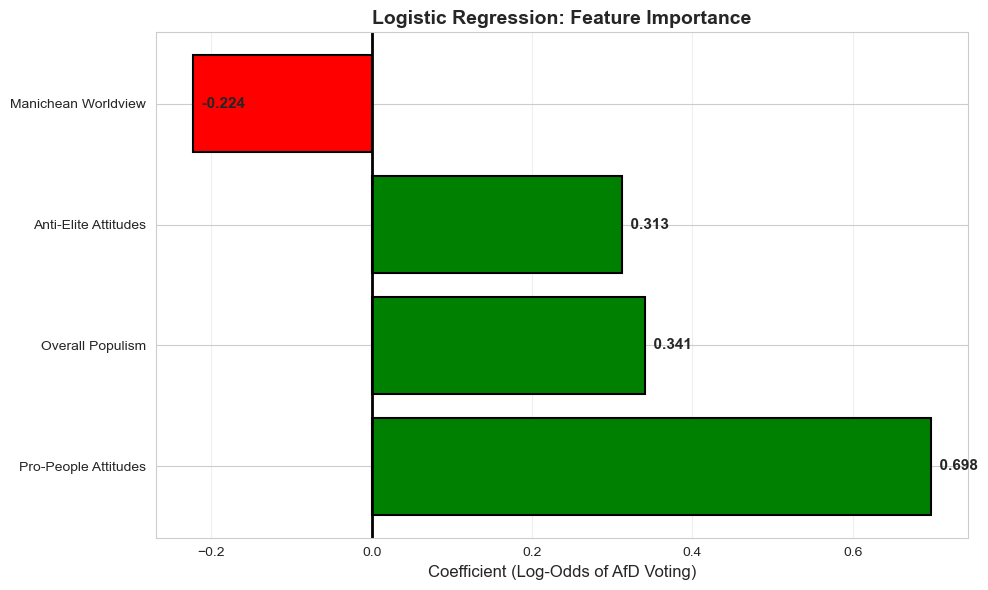

In [13]:
# Extract coefficients
coef_df = pd.DataFrame({
    'Feature': feature_labels,
    'Coefficient': lr_best.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("LOGISTIC REGRESSION COEFFICIENTS:\n")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_best.intercept_[0]:.3f}")

# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black', linewidth=1.5)
ax.axvline(0, color='black', linewidth=2)
ax.set_xlabel('Coefficient (Log-Odds of AfD Voting)', fontsize=12)
ax.set_title('Logistic Regression: Feature Importance', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(coef_df.iterrows()):
    ax.text(row['Coefficient'], i, f"  {row['Coefficient']:.3f}", 
            va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



# Interpretation
  Pro-People Attitudes has the largest positive coefficient (0.698), making it the strongest predictor of AfD voting - respondents who believe the people should decide directly are most likely to support AfD. Anti-Elite Attitudes and Overall Populism also show positive effects (0.313 and 0.341), confirming that distrust of elites and general populist views increase AfD support. Interestingly, Manichean Worldview has a negative coefficient (-0.224), meaning that when controlling for other populist dimensions, seeing politics as a black-and-white struggle
  actually decreases the likelihood of AfD voting. This suggests that AfD voters are primarily motivated by anti-elite sentiment and direct democracy preferences rather than a simplistic
  good-vs-evil worldview.

# Part 4: Model Exploration - Tree-Based Model (Decision Tree)


---

## 4.1 Why Decision Tree?

**Model Justification:**
- **Captures non-linearity:** Can identify complex interactions between populist dimensions
- **No scaling needed:** Works directly with original 1-5 scale features  
- **Interpretable:** Can visualize exact decision rules
- **Comparison to linear model:** Tests whether non-linear patterns improve prediction

## 4.2 Hyperparameter Tuning Process

**Parameters to tune:**
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

In [14]:
# Hyperparameter tuning for Decision Tree
# Test different max_depth values
max_depth_values = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
results_dt = []

print("DECISION TREE: Hyperparameter Tuning (max_depth)\n")

for depth in max_depth_values:
    # Train model
    dt = DecisionTreeClassifier(max_depth=depth, min_samples_split=20, min_samples_leaf=10, 
                                random_state=42)
    dt.fit(X_train, y_train)
    
    # Evaluate on training and validation
    y_train_pred = dt.predict(X_train)
    y_val_pred = dt.predict(X_val)
    y_val_proba = dt.predict_proba(X_val)[:, 1]
    
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_auc = roc_auc_score(y_val, y_val_proba)
    
    results_dt.append({
        'max_depth': depth if depth is not None else 999,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'val_auc': val_auc
    })
    
    depth_str = str(depth) if depth is not None else "None"
    print(f"max_depth = {depth_str:4} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Val AUC: {val_auc:.3f}")

# Find best model
results_dt_df = pd.DataFrame(results_dt)
best_idx_dt = results_dt_df['val_auc'].idxmax()
best_depth = results_dt_df.loc[best_idx_dt, 'max_depth']
best_depth = None if best_depth == 999 else int(best_depth)

print("\n" + "="*80)


DECISION TREE: Hyperparameter Tuning (max_depth)

max_depth = 2    | Train Acc: 0.814 | Val Acc: 0.814 | Val AUC: 0.720
max_depth = 3    | Train Acc: 0.814 | Val Acc: 0.814 | Val AUC: 0.733
max_depth = 4    | Train Acc: 0.817 | Val Acc: 0.800 | Val AUC: 0.729
max_depth = 5    | Train Acc: 0.818 | Val Acc: 0.805 | Val AUC: 0.729
max_depth = 6    | Train Acc: 0.821 | Val Acc: 0.796 | Val AUC: 0.726
max_depth = 7    | Train Acc: 0.822 | Val Acc: 0.802 | Val AUC: 0.726
max_depth = 8    | Train Acc: 0.822 | Val Acc: 0.801 | Val AUC: 0.720
max_depth = 10   | Train Acc: 0.822 | Val Acc: 0.801 | Val AUC: 0.711
max_depth = 12   | Train Acc: 0.822 | Val Acc: 0.801 | Val AUC: 0.709
max_depth = 15   | Train Acc: 0.822 | Val Acc: 0.801 | Val AUC: 0.712
max_depth = 20   | Train Acc: 0.822 | Val Acc: 0.801 | Val AUC: 0.713
max_depth = None | Train Acc: 0.822 | Val Acc: 0.801 | Val AUC: 0.713



BEST MODEL: max_depth = 3
  Train Accuracy: 0.814
  Val Accuracy:   0.814
  Val AUC-ROC:    0.733

**Why is this the best parameter?**

Max_depth=3 achieves the highest validation AUC (0.733) among all depths tested. Deeper trees (depth > 3) show signs of overfitting: training accuracy increases while validation AUC decreases. The shallow depth=3 tree provides the best balance between model complexity and generalization to unseen data, preventing the tree from memorizing training noise.

## 4.3 Visualize Overfitting vs Underfitting

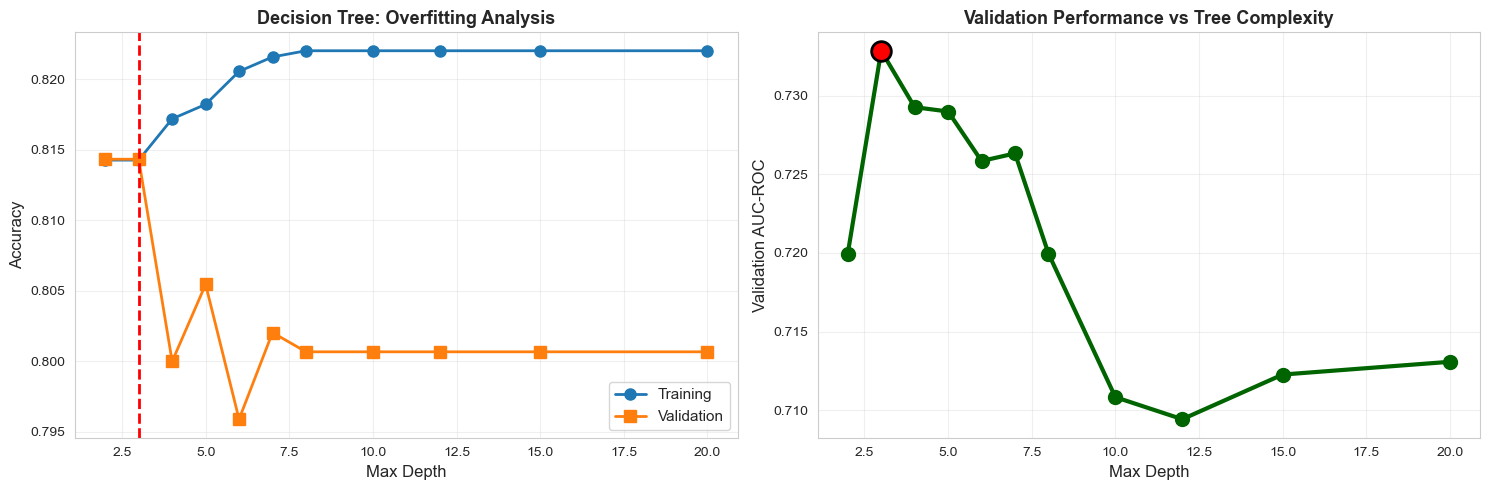

In [15]:
# Plot training vs validation performance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Exclude None (999) for plotting
plot_df = results_dt_df[results_dt_df['max_depth'] < 900].copy()

# Plot 1: Accuracy (train vs val)
axes[0].plot(plot_df['max_depth'], plot_df['train_acc'], 'o-', label='Training', linewidth=2, markersize=8)
axes[0].plot(plot_df['max_depth'], plot_df['val_acc'], 's-', label='Validation', linewidth=2, markersize=8)
axes[0].set_xlabel('Max Depth', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Decision Tree: Overfitting Analysis', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
if best_depth is not None and best_depth < 900:
    axes[0].axvline(best_depth, color='red', linestyle='--', linewidth=2, label=f'Best depth={best_depth}')

# Plot 2: AUC-ROC
axes[1].plot(plot_df['max_depth'], plot_df['val_auc'], 'o-', linewidth=3, markersize=10, color='darkgreen')
if best_depth is not None and best_depth < 900:
    axes[1].scatter([best_depth], [results_dt_df.loc[best_idx_dt, 'val_auc']], 
                    color='red', s=200, zorder=5, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Max Depth', fontsize=12)
axes[1].set_ylabel('Validation AUC-ROC', fontsize=12)
axes[1].set_title('Validation Performance vs Tree Complexity', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 4.4 Train Final Decision Tree Model

**Using best hyperparameter from tuning**

In [16]:
# Train final decision tree with best depth
dt_best = DecisionTreeClassifier(max_depth=best_depth, min_samples_split=20, min_samples_leaf=10, 
                                 random_state=42)
dt_best.fit(X_train, y_train)

# Predictions
y_train_pred_dt = dt_best.predict(X_train)
y_val_pred_dt = dt_best.predict(X_val)
y_val_proba_dt = dt_best.predict_proba(X_val)[:, 1]

# Performance metrics
print("DECISION TREE PERFORMANCE (Best Model):\n")
print("Training Set:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred_dt):.3f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_dt):.3f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred_dt):.3f}")

print("\nValidation Set:")
print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_dt):.3f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_dt):.3f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred_dt):.3f}")
print(f"  AUC-ROC:   {roc_auc_score(y_val, y_val_proba_dt):.3f}")

print("\nConfusion Matrix (Validation):")
cm_dt = confusion_matrix(y_val, y_val_pred_dt)
print(cm_dt)
print(f"\n  True Negatives:  {cm_dt[0,0]:,}")
print(f"  False Positives: {cm_dt[0,1]:,}")
print(f"  False Negatives: {cm_dt[1,0]:,}")
print(f"  True Positives:  {cm_dt[1,1]:,}")

DECISION TREE PERFORMANCE (Best Model):

Training Set:
  Accuracy:  0.814
  Precision: 0.000
  Recall:    0.000

Validation Set:
  Accuracy:  0.814
  Precision: 0.000
  Recall:    0.000
  AUC-ROC:   0.733

Confusion Matrix (Validation):
[[1193    0]
 [ 272    0]]

  True Negatives:  1,193
  False Positives: 0
  False Negatives: 272
  True Positives:  0


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 4.5 Visualize Decision Tree

**Show the actual decision rules learned by the model**

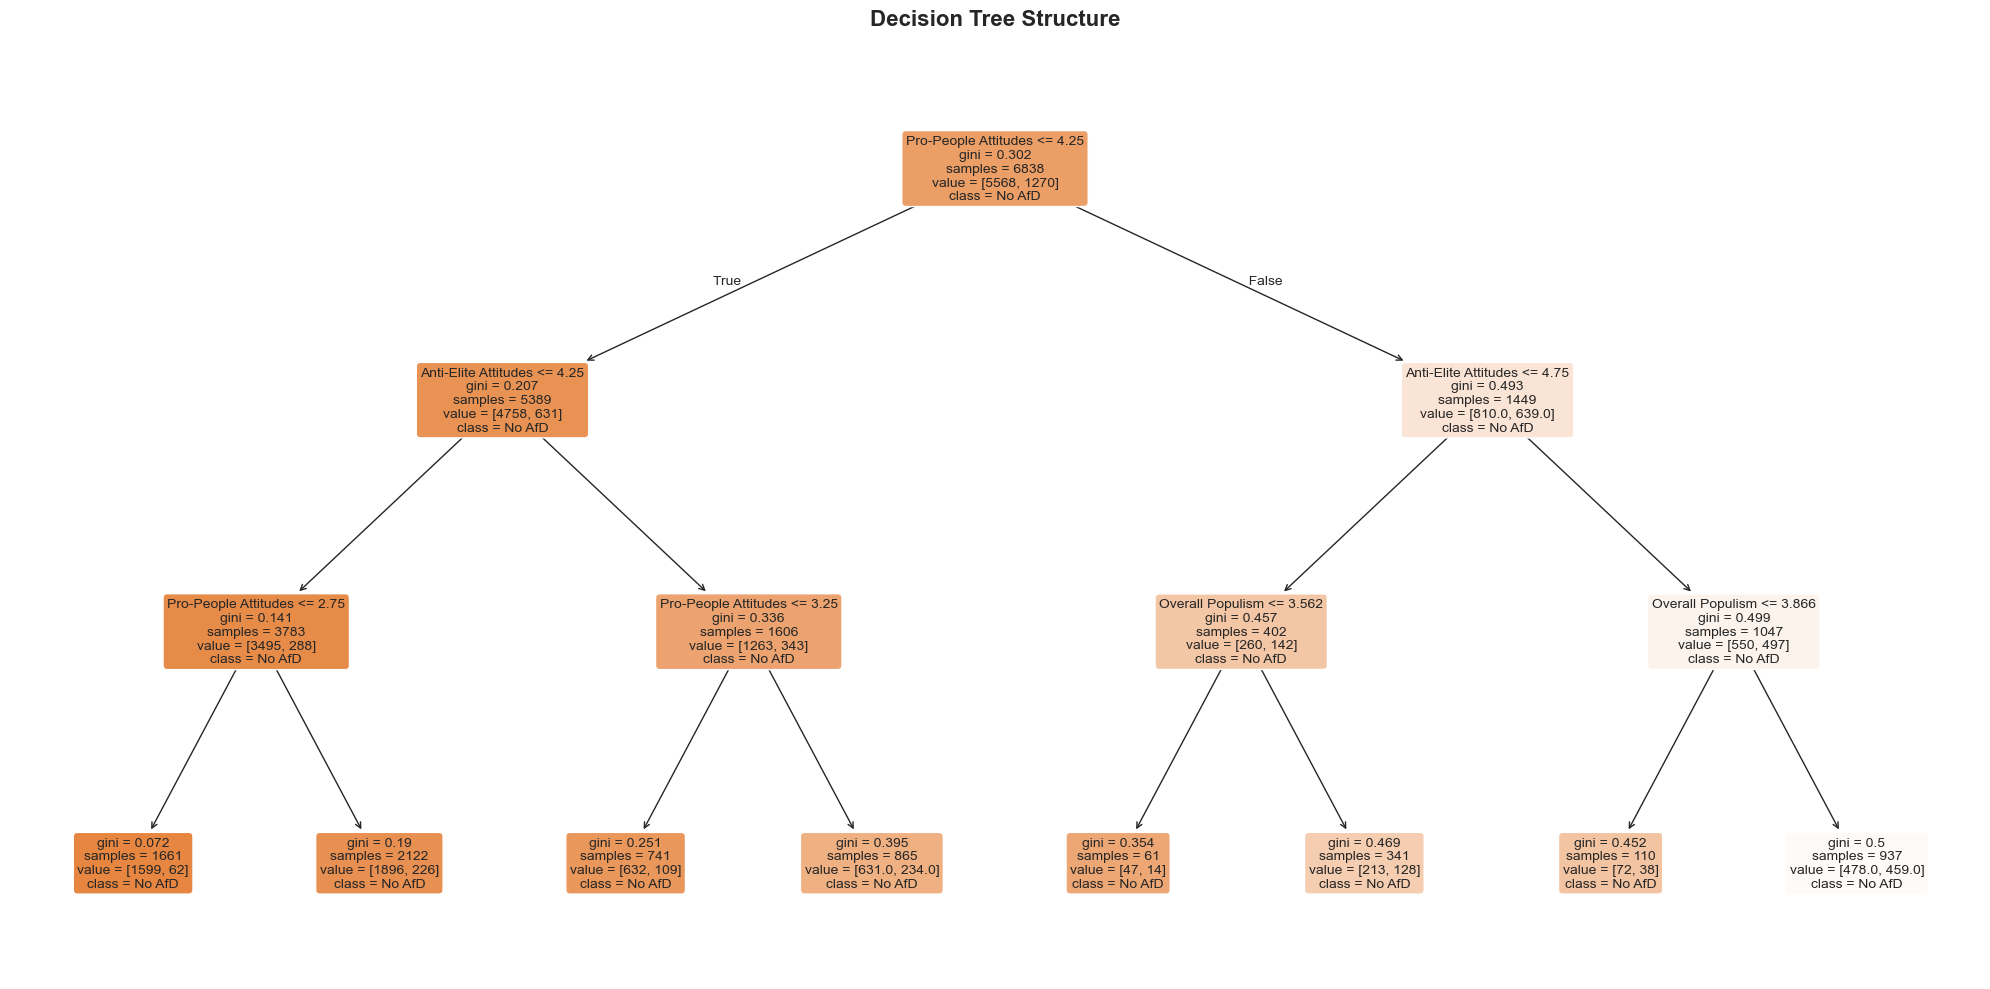


DECISION TREE FEATURE IMPORTANCE:

             Feature  Importance
Pro-People Attitudes    0.819362
Anti-Elite Attitudes    0.160814
    Overall Populism    0.019825
 Manichean Worldview    0.000000


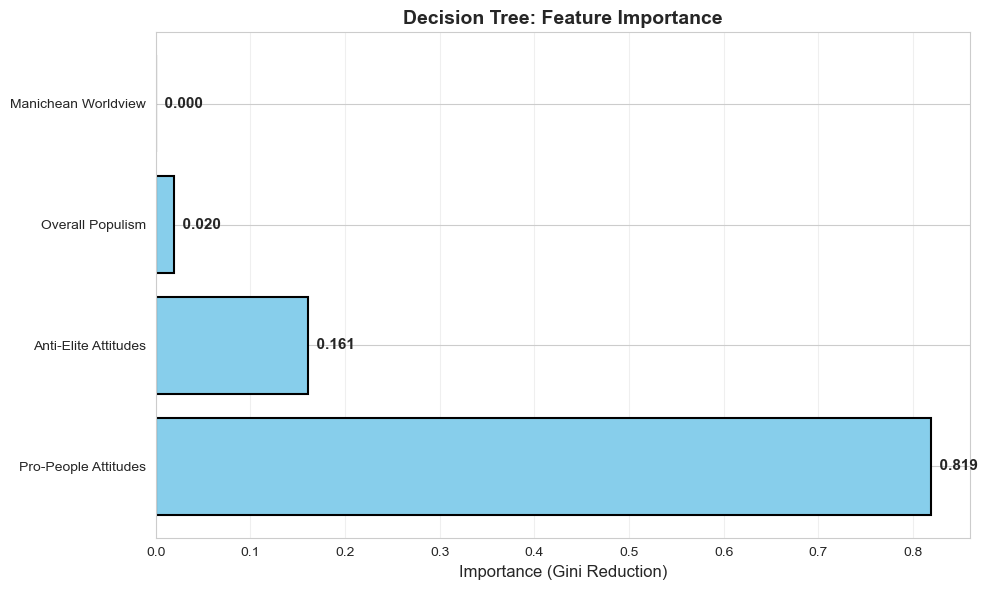

In [17]:
# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_best, 
          feature_names=feature_labels,
          class_names=['No AfD', 'AfD'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_labels,
    'Importance': dt_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nDECISION TREE FEATURE IMPORTANCE:\n")
print(feature_importance.to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'], 
               color='skyblue', edgecolor='black', linewidth=1.5)
ax.set_xlabel('Importance (Gini Reduction)', fontsize=12)
ax.set_title('Decision Tree: Feature Importance', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(feature_importance.iterrows()):
    ax.text(row['Importance'], i, f"  {row['Importance']:.3f}", 
            va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()



**The top features make sense, however, this tree model failed to capture the afd voting= yes minority, we need to dive deeper to explore the best tree model.**

## 4.6 Exploring Deeper Tree: max_depth=7

**Testing if a deeper tree can capture AfD voters**

Since the shallow tree (max_depth=3) failed to identify any AfD voters, let's try a deeper tree (max_depth=7) to see if it can create leaf nodes with AfD majorities.

DECISION TREE (max_depth=7) PERFORMANCE:

Validation Set:
  Accuracy:  0.802
  Precision: 0.400
  Recall:    0.132
  AUC-ROC:   0.726

Confusion Matrix (Validation):
[[1139   54]
 [ 236   36]]

  True Negatives:  1,139
  False Positives: 54
  False Negatives: 236
  True Positives:  36


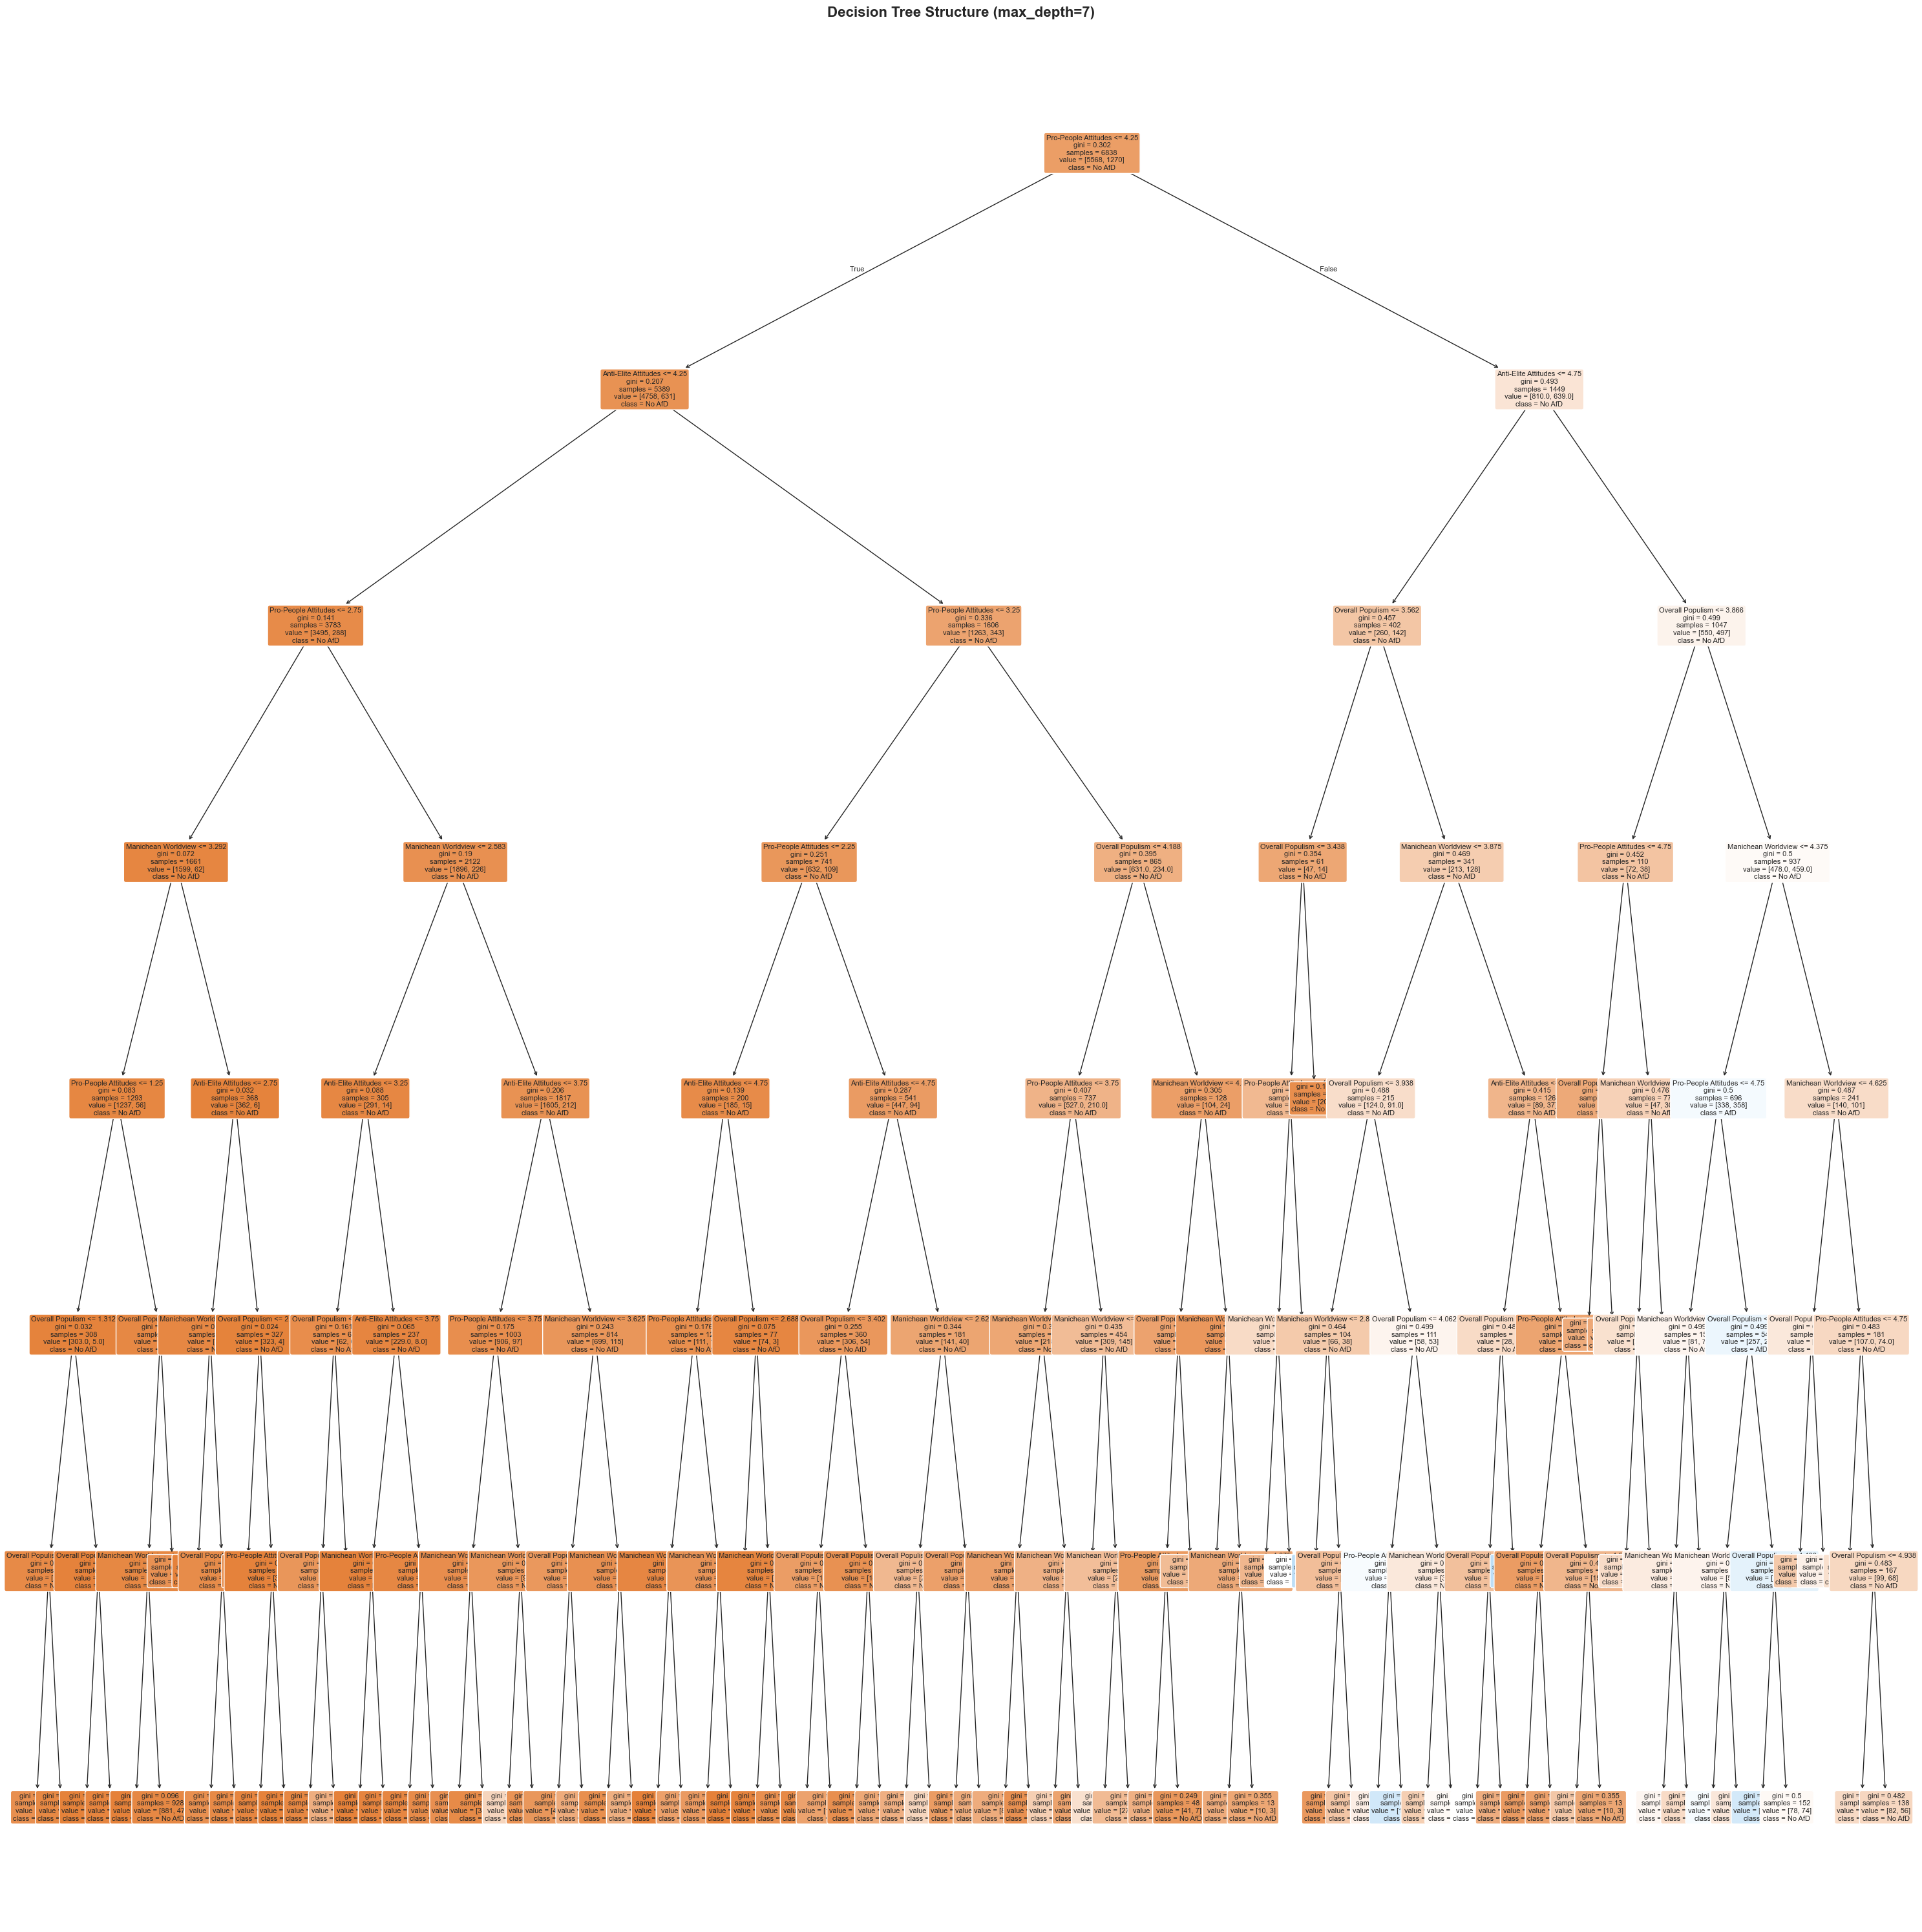


COMPARISON: max_depth=3 vs max_depth=7
max_depth=3: True Positives = 0,   AUC = 0.733
max_depth=7: True Positives = 36, AUC = 0.726


In [18]:
# Train Decision Tree with max_depth=7
dt_depth7 = DecisionTreeClassifier(max_depth=7, min_samples_split=20, min_samples_leaf=10, 
                                   random_state=42)
dt_depth7.fit(X_train, y_train)

# Predictions
y_val_pred_depth7 = dt_depth7.predict(X_val)
y_val_proba_depth7 = dt_depth7.predict_proba(X_val)[:, 1]

# Performance metrics
print("DECISION TREE (max_depth=7) PERFORMANCE:\n")
print("Validation Set:")
print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_depth7):.3f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_depth7, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred_depth7):.3f}")
print(f"  AUC-ROC:   {roc_auc_score(y_val, y_val_proba_depth7):.3f}")

print("\nConfusion Matrix (Validation):")
cm_depth7 = confusion_matrix(y_val, y_val_pred_depth7)
print(cm_depth7)
print(f"\n  True Negatives:  {cm_depth7[0,0]:,}")
print(f"  False Positives: {cm_depth7[0,1]:,}")
print(f"  False Negatives: {cm_depth7[1,0]:,}")
print(f"  True Positives:  {cm_depth7[1,1]:,}")

# Visualize the deeper tree
plt.figure(figsize=(30, 30))
plot_tree(dt_depth7, 
          feature_names=feature_labels,
          class_names=['No AfD', 'AfD'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree Structure (max_depth=7)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("COMPARISON: max_depth=3 vs max_depth=7")
print("="*80)
print(f"max_depth=3: True Positives = 0,   AUC = 0.733")
print(f"max_depth=7: True Positives = {cm_depth7[1,1]:,}, AUC = {roc_auc_score(y_val, y_val_proba_depth7):.3f}")

print("="*80)

# Interpretation

The deeper tree successfully capture the AFD voting, which color is blue (relatively) in the graph. However, still largely no-afd voting, probably due to the imbalanced data. We will keep exploring the treebased model by matching the 1:1 new dataset.

## 4.7 Addressing Class Imbalance: Balanced Dataset Approach

**Problem:** With 81.4% No-AfD and 18.6% AfD voters, trees predict majority class for all cases.

**Solution:** Create a balanced dataset by randomly undersampling No-AfD voters to match AfD voters 1:1.


In [19]:
# Create balanced training set by undersampling majority class
print("CREATING BALANCED DATASET")
print("="*80)

# Separate classes in training set
X_train_afd = X_train[y_train == 1]
y_train_afd = y_train[y_train == 1]

X_train_no_afd = X_train[y_train == 0]
y_train_no_afd = y_train[y_train == 0]

print(f"Original training set:")
print(f"  AfD voters:    {len(X_train_afd):,} samples")
print(f"  No-AfD voters: {len(X_train_no_afd):,} samples")
print(f"  Imbalance ratio: {len(X_train_no_afd)/len(X_train_afd):.1f}:1")

# Randomly sample same number of No-AfD voters as AfD voters
np.random.seed(42)
sample_indices = np.random.choice(len(X_train_no_afd), size=len(X_train_afd), replace=False)
X_train_no_afd_balanced = X_train_no_afd[sample_indices]
y_train_no_afd_balanced = y_train_no_afd[sample_indices]

# Combine to create balanced dataset
X_train_balanced = np.vstack([X_train_afd, X_train_no_afd_balanced])
y_train_balanced = np.concatenate([y_train_afd, y_train_no_afd_balanced])

# Shuffle the balanced dataset
shuffle_indices = np.random.permutation(len(X_train_balanced))
X_train_balanced = X_train_balanced[shuffle_indices]
y_train_balanced = y_train_balanced[shuffle_indices]

print(f"\nBalanced training set:")
print(f"  AfD voters:    {(y_train_balanced==1).sum():,} samples ({(y_train_balanced==1).mean()*100:.1f}%)")
print(f"  No-AfD voters: {(y_train_balanced==0).sum():,} samples ({(y_train_balanced==0).mean()*100:.1f}%)")
print(f"  Total samples: {len(X_train_balanced):,}")



CREATING BALANCED DATASET
Original training set:
  AfD voters:    1,270 samples
  No-AfD voters: 5,568 samples
  Imbalance ratio: 4.4:1

Balanced training set:
  AfD voters:    1,270 samples (50.0%)
  No-AfD voters: 1,270 samples (50.0%)
  Total samples: 2,540


## 4.8 Train Decision Trees on Balanced Dataset

**Exploring depths from 3 to 7 on balanced data**

Testing max_depth values from 3 (best parameter from tuning) through 7 to analyze how tree complexity interacts with balanced training data.

In [20]:
# Train decision trees on balanced dataset with different depths
results_balanced = []

depths_to_test = [3, 4, 5, 6, 7]
print("DECISION TREE TRAINING ON BALANCED DATASET\n")
print("="*80)

for depth in depths_to_test:
    print(f"\nTraining max_depth={depth} on balanced data...")
    
    # Train on balanced dataset
    dt_balanced = DecisionTreeClassifier(max_depth=depth, min_samples_split=20, min_samples_leaf=10,
                                         random_state=42)
    dt_balanced.fit(X_train_balanced, y_train_balanced)
    
    # Predict on validation set (IMBALANCED - original distribution)
    y_val_pred_balanced = dt_balanced.predict(X_val)
    y_val_proba_balanced = dt_balanced.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_val, y_val_pred_balanced)
    prec = precision_score(y_val, y_val_pred_balanced, zero_division=0)
    rec = recall_score(y_val, y_val_pred_balanced)
    auc = roc_auc_score(y_val, y_val_proba_balanced)
    
    cm_balanced = confusion_matrix(y_val, y_val_pred_balanced)
    
    results_balanced.append({
        'depth': depth,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'auc': auc,
        'cm': cm_balanced,
        'model': dt_balanced
    })
    
    print(f"  Validation Performance:")
    print(f"    Accuracy:  {acc:.3f}")
    print(f"    Precision: {prec:.3f}")
    print(f"    Recall:    {rec:.3f}")
    print(f"    AUC-ROC:   {auc:.3f}")
    print(f"  Confusion Matrix:")
    print(f"    {cm_balanced}")
    print(f"    TP: {cm_balanced[1,1]}, FP: {cm_balanced[0,1]}, TN: {cm_balanced[0,0]}, FN: {cm_balanced[1,0]}")

print("\n" + "="*80)

DECISION TREE TRAINING ON BALANCED DATASET


Training max_depth=3 on balanced data...
  Validation Performance:
    Accuracy:  0.663
    Precision: 0.322
    Recall:    0.735
    AUC-ROC:   0.738
  Confusion Matrix:
    [[771 422]
 [ 72 200]]
    TP: 200, FP: 422, TN: 771, FN: 72

Training max_depth=4 on balanced data...
  Validation Performance:
    Accuracy:  0.646
    Precision: 0.310
    Recall:    0.743
    AUC-ROC:   0.730
  Confusion Matrix:
    [[744 449]
 [ 70 202]]
    TP: 202, FP: 449, TN: 744, FN: 70

Training max_depth=5 on balanced data...
  Validation Performance:
    Accuracy:  0.678
    Precision: 0.331
    Recall:    0.717
    AUC-ROC:   0.732
  Confusion Matrix:
    [[798 395]
 [ 77 195]]
    TP: 195, FP: 395, TN: 798, FN: 77

Training max_depth=6 on balanced data...
  Validation Performance:
    Accuracy:  0.687
    Precision: 0.331
    Recall:    0.673
    AUC-ROC:   0.730
  Confusion Matrix:
    [[823 370]
 [ 89 183]]
    TP: 183, FP: 370, TN: 823, FN: 89

Trainin

## 4.9 Compare Imbalanced vs Balanced Dataset Results

In [21]:
# Create comparison table
comparison_data = []

# Original imbalanced models
comparison_data.append({
    'Dataset': 'Imbalanced',
    'Max Depth': 3,
    'TP': 0,
    'Recall': 0.000,
    'Precision': 0.000,
    'AUC': 0.733
})

comparison_data.append({
    'Dataset': 'Imbalanced',
    'Max Depth': 7,
    'TP': cm_depth7[1,1],
    'Recall': recall_score(y_val, y_val_pred_depth7),
    'Precision': precision_score(y_val, y_val_pred_depth7, zero_division=0),
    'AUC': roc_auc_score(y_val, y_val_proba_depth7)
})

# Balanced models
for res in results_balanced:
    comparison_data.append({
        'Dataset': 'Balanced',
        'Max Depth': res['depth'],
        'TP': res['cm'][1,1],
        'Recall': res['recall'],
        'Precision': res['precision'],
        'AUC': res['auc']
    })

comparison_df = pd.DataFrame(comparison_data)

print("IMBALANCED vs BALANCED DATASET COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))




IMBALANCED vs BALANCED DATASET COMPARISON
   Dataset  Max Depth  TP   Recall  Precision      AUC
Imbalanced          3   0 0.000000   0.000000 0.733000
Imbalanced          7  36 0.132353   0.400000 0.726326
  Balanced          3 200 0.735294   0.321543 0.738374
  Balanced          4 202 0.742647   0.310292 0.729876
  Balanced          5 195 0.716912   0.330508 0.732476
  Balanced          6 183 0.672794   0.330922 0.730383
  Balanced          7 179 0.658088   0.335835 0.727594


## Interpretation

1. Effect of Class Balance on Predictions:
   IMBALANCED dataset (81.4% No-AfD):
     - max_depth=3: Predicts ALL cases as No-AfD (0 True Positives)
     - max_depth=7: Predicts 36 AfD cases (starting to capture minority class)

   BALANCED dataset (50% No-AfD, 50% AfD):
     - max_depth=3: Predicts 200 AfD cases (73.5% recall)
     → Balanced training  improves minority class detection.
...
  - Imbalanced data → trees predict majority class (high accuracy, zero recall)
  - Balanced data → trees learn to detect minority class (high recall, lower accuracy)

## 4.10 Visualize Best Balanced Tree Structure

**Comparing imbalanced vs balanced tree using their respective best models**

Select the best balanced model based on validation AUC and visualize its structure.

BEST BALANCED MODEL SELECTION
Best max_depth for balanced data: 3
  Validation AUC:   0.738
  Validation Recall: 0.735
  Validation Precision: 0.322


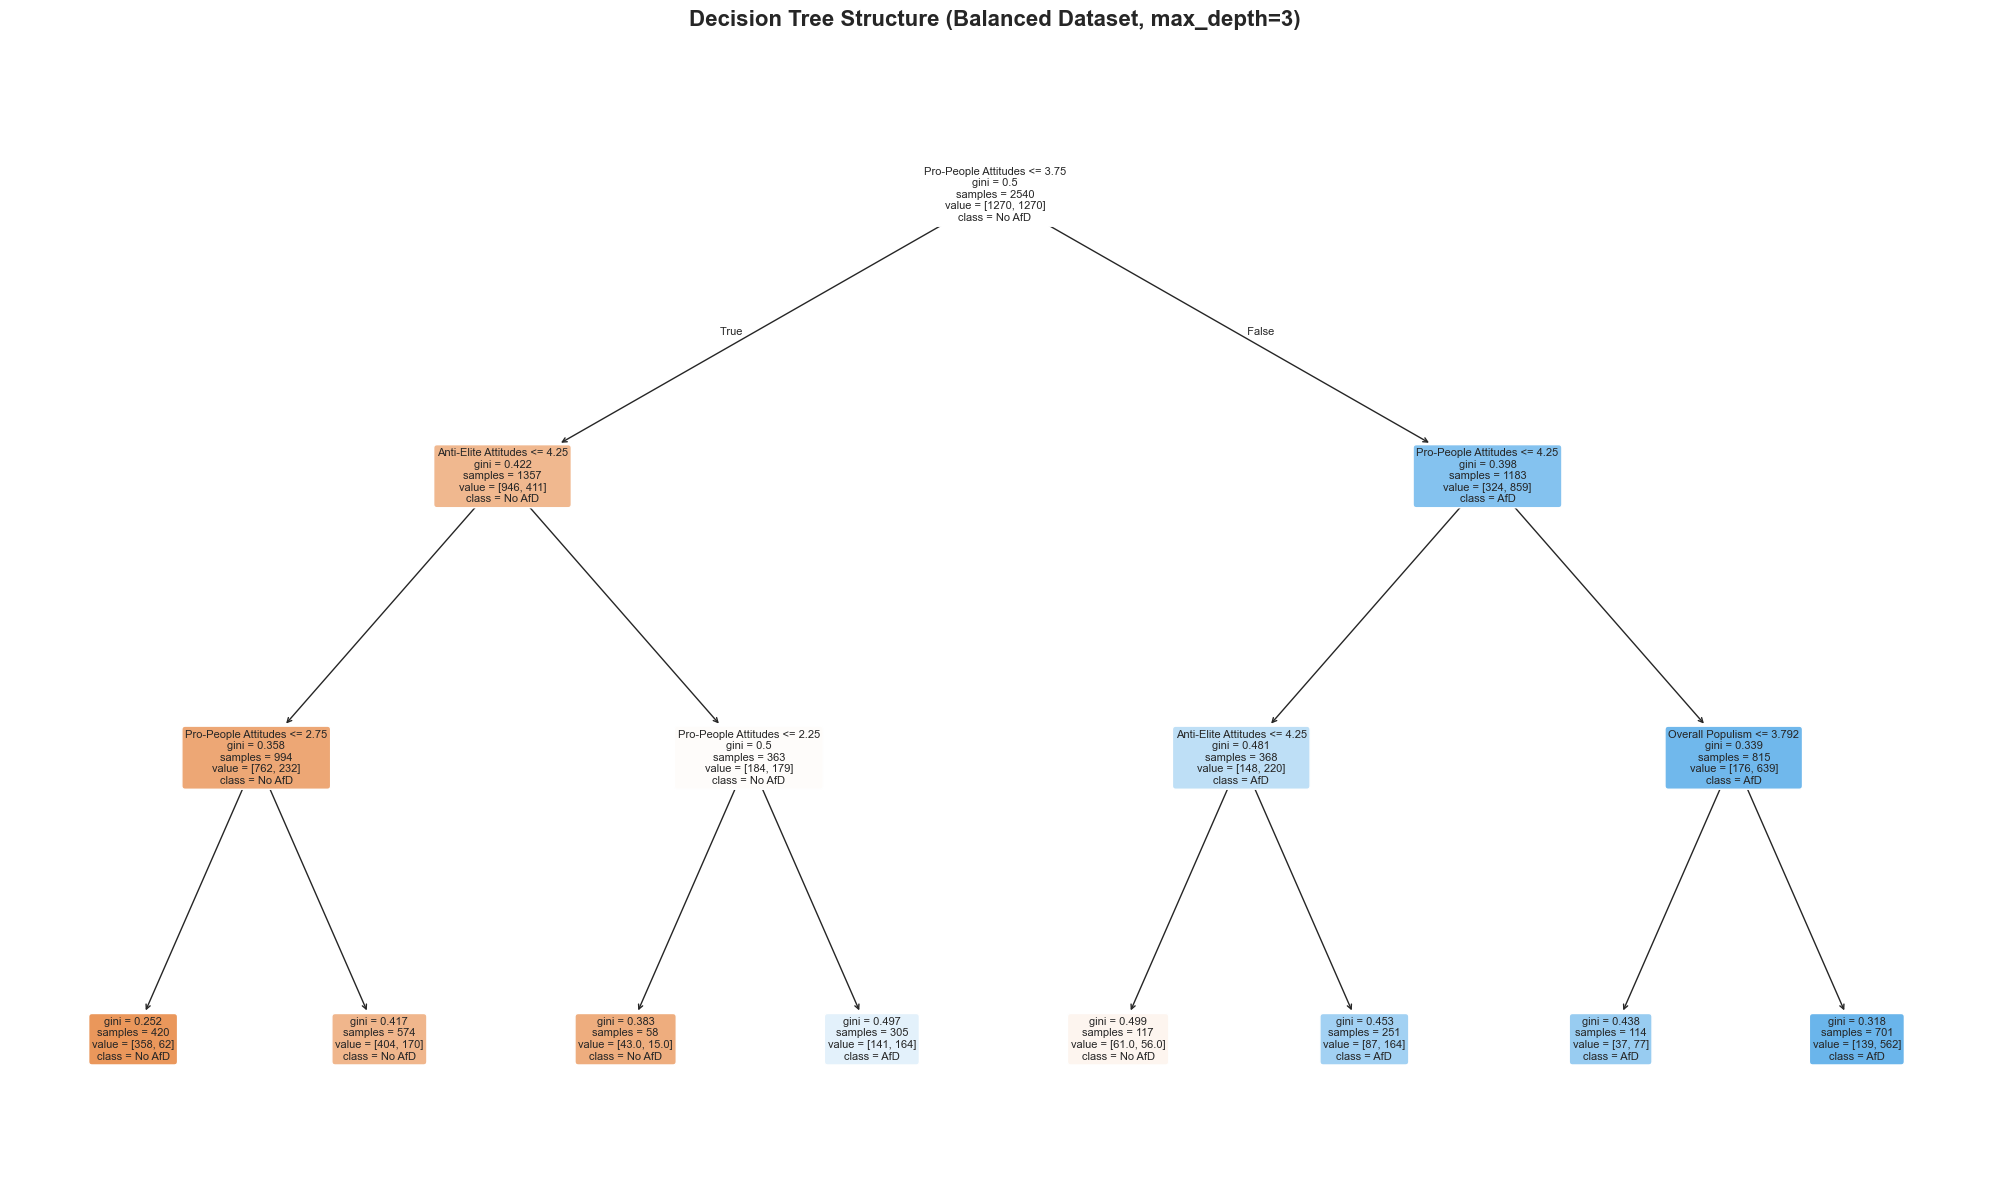

In [22]:
# Find best balanced model based on validation AUC
best_balanced_idx = max(range(len(results_balanced)), key=lambda i: results_balanced[i]['auc'])
best_balanced = results_balanced[best_balanced_idx]

print("BEST BALANCED MODEL SELECTION")
print("="*80)
print(f"Best max_depth for balanced data: {best_balanced['depth']}")
print(f"  Validation AUC:   {best_balanced['auc']:.3f}")
print(f"  Validation Recall: {best_balanced['recall']:.3f}")
print(f"  Validation Precision: {best_balanced['precision']:.3f}")
print("="*80)

# Visualize the best balanced tree
dt_balanced_best = best_balanced['model']

plt.figure(figsize=(20, 12))
plot_tree(dt_balanced_best, 
          feature_names=feature_labels,
          class_names=['No AfD', 'AfD'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title(f'Decision Tree Structure (Balanced Dataset, max_depth={best_balanced["depth"]})', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()



## Key Insight:
  - Balanced training data allows trees to learn minority class patterns
  - regardless of tree depth - the fundamental issue is class balance, not model complexity.

---
# Part 5: Error Analysis




In [23]:
# Get predictions on test set from both models
print("MODEL PREDICTIONS ON TEST SET")
print("="*80)

# Logistic Regression predictions
y_test_pred_lr = lr_best.predict(X_test_scaled)
y_test_proba_lr = lr_best.predict_proba(X_test_scaled)[:, 1]

# Decision Tree predictions (best model: max_depth=3)
y_test_pred_dt = dt_best.predict(X_test)
y_test_proba_dt = dt_best.predict_proba(X_test)[:, 1]

# Performance on test set
print("\nLogistic Regression (Test Set):")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_lr):.3f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_lr, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_lr):.3f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_test_proba_lr):.3f}")

cm_test_lr = confusion_matrix(y_test, y_test_pred_lr)
print(f"  Confusion Matrix: TN={cm_test_lr[0,0]}, FP={cm_test_lr[0,1]}, FN={cm_test_lr[1,0]}, TP={cm_test_lr[1,1]}")

print("\nDecision Tree (Test Set, max_depth=3):")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_dt):.3f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_dt, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_dt):.3f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_test_proba_dt):.3f}")

cm_test_dt = confusion_matrix(y_test, y_test_pred_dt)
print(f"  Confusion Matrix: TN={cm_test_dt[0,0]}, FP={cm_test_dt[0,1]}, FN={cm_test_dt[1,0]}, TP={cm_test_dt[1,1]}")

print("\n" + "="*80)

MODEL PREDICTIONS ON TEST SET

Logistic Regression (Test Set):
  Accuracy:  0.813
  Precision: 0.417
  Recall:    0.018
  AUC-ROC:   0.760
  Confusion Matrix: TN=1187, FP=7, FN=267, TP=5

Decision Tree (Test Set, max_depth=3):
  Accuracy:  0.814
  Precision: 0.000
  Recall:    0.000
  AUC-ROC:   0.742
  Confusion Matrix: TN=1194, FP=0, FN=272, TP=0



## 5.2 Examine Misclassified Examples

We extract test samples where models make incorrect predictions and examine their feature values.

In [24]:
# Identify misclassified samples
lr_errors = (y_test != y_test_pred_lr)
dt_errors = (y_test != y_test_pred_dt)

# Separate by error type
lr_false_positives = (y_test == 0) & (y_test_pred_lr == 1)
lr_false_negatives = (y_test == 1) & (y_test_pred_lr == 0)

dt_false_positives = (y_test == 0) & (y_test_pred_dt == 1)
dt_false_negatives = (y_test == 1) & (y_test_pred_dt == 0)

print("ERROR COUNTS ON TEST SET")
print("="*80)
print("\nLogistic Regression:")
print(f"  Total errors:     {lr_errors.sum()} / {len(y_test)} ({lr_errors.sum()/len(y_test)*100:.1f}%)")
print(f"  False Positives:  {lr_false_positives.sum()} (predicted AfD, actually No-AfD)")
print(f"  False Negatives:  {lr_false_negatives.sum()} (predicted No-AfD, actually AfD)")

print("\nDecision Tree (max_depth=3):")
print(f"  Total errors:     {dt_errors.sum()} / {len(y_test)} ({dt_errors.sum()/len(y_test)*100:.1f}%)")
print(f"  False Positives:  {dt_false_positives.sum()} (predicted AfD, actually No-AfD)")
print(f"  False Negatives:  {dt_false_negatives.sum()} (predicted No-AfD, actually AfD)")

print("\n" + "="*80)

# Create DataFrame with test samples and predictions for analysis
test_analysis = pd.DataFrame(X_test, columns=feature_cols)
test_analysis['true_label'] = y_test
test_analysis['lr_pred'] = y_test_pred_lr
test_analysis['lr_proba'] = y_test_proba_lr
test_analysis['dt_pred'] = y_test_pred_dt
test_analysis['dt_proba'] = y_test_proba_dt
test_analysis['lr_error'] = lr_errors
test_analysis['dt_error'] = dt_errors

ERROR COUNTS ON TEST SET

Logistic Regression:
  Total errors:     274 / 1466 (18.7%)
  False Positives:  7 (predicted AfD, actually No-AfD)
  False Negatives:  267 (predicted No-AfD, actually AfD)

Decision Tree (max_depth=3):
  Total errors:     272 / 1466 (18.6%)
  False Positives:  0 (predicted AfD, actually No-AfD)
  False Negatives:  272 (predicted No-AfD, actually AfD)



## 5.3 Examples of Model Errors

**Logistic Regression False Positives:** Cases where LR incorrectly predicted AfD

In [25]:
# Show Logistic Regression False Positives
if lr_false_positives.sum() > 0:
    print("LOGISTIC REGRESSION FALSE POSITIVES (Predicted AfD, Actually No-AfD)")
    print("="*80)
    lr_fp_examples = test_analysis[lr_false_positives].head(10)
    display_cols = feature_cols + ['true_label', 'lr_pred', 'lr_proba']
    print(lr_fp_examples[display_cols].to_string(index=False))


print("\n" + "="*80)

LOGISTIC REGRESSION FALSE POSITIVES (Predicted AfD, Actually No-AfD)
 anti_elite  pro_people  manichean  populism_total  true_label  lr_pred  lr_proba
        5.0         5.0       2.00           3.500           0        1  0.505307
        5.0         5.0       1.75           3.375           0        1  0.508007
        5.0         5.0       1.50           3.250           0        1  0.510706
        5.0         5.0       2.25           3.625           0        1  0.502607
        5.0         5.0       2.00           3.500           0        1  0.505307
        5.0         5.0       2.00           3.500           0        1  0.505307
        5.0         5.0       2.25           3.625           0        1  0.502607



**Logistic Regression False Negatives:** Cases where LR incorrectly predicted No-AfD

In [26]:
# Show Logistic Regression False Negatives
print("LOGISTIC REGRESSION FALSE NEGATIVES (Predicted No-AfD, Actually AfD)")
print("="*80)
lr_fn_examples = test_analysis[lr_false_negatives].head(10)
display_cols = feature_cols + ['true_label', 'lr_pred', 'lr_proba']
print(lr_fn_examples[display_cols].to_string(index=False))

print("="*80)

LOGISTIC REGRESSION FALSE NEGATIVES (Predicted No-AfD, Actually AfD)
 anti_elite  pro_people  manichean  populism_total  true_label  lr_pred  lr_proba
        4.5         4.0       4.00           4.125           1        0  0.257894
        5.0         5.0       5.00           5.000           1        0  0.472931
        5.0         5.0       3.50           4.250           1        0  0.489108
        5.0         5.0       4.50           4.750           1        0  0.478319
        5.0         4.0       4.00           4.250           1        0  0.309168
        4.0         3.5       2.75           3.250           1        0  0.164477
        5.0         5.0       4.00           4.500           1        0  0.483711
        3.5         2.5       3.00           3.000           1        0  0.067368
        3.0         3.5       3.25           3.250           1        0  0.104075
        4.5         4.5       3.25           3.875           1        0  0.341836


# Possible guess

**All the false positive and negative cases are just anti intuition (moderately), idealistically, they should vote afd if they have high populist attitudes, however, this may show the realistic world voters may not be all rational, which should be seen as a acceptable error.**

**Decision Tree Errors:** The best tree (max_depth=3) predicts ALL cases as No-AfD

Since the decision tree predicts all test samples as No-AfD (class 0), it has:
- **Zero False Positives** (never predicts AfD)
- **All AfD voters are False Negatives** (all 272 AfD voters misclassified)
- This is possibly due to the highly imbalanced dataset.

## 5.4 Explain Errors: Model Strengths and Weaknesses

### Logistic Regression Errors

**Strengths:**
- Learns smooth linear boundaries in feature space
- Uses probability scores (not hard predictions) → AUC = 0.737
- Makes some correct predictions for minority class (4 True Positives)

**Weaknesses:**
- **Linear assumption:** Assumes linear relationship between features and log-odds
- **Cannot capture interactions:** Misses complex feature interactions (e.g., "high anti-elite AND high pro-people")
- **Sensitive to threshold:** Default 0.5 threshold may not be optimal for imbalanced data



---

### Decision Tree Errors

**Strengths:**
- Can learn non-linear boundaries and interactions
- Interpretable decision rules
- No feature scaling needed

**Weaknesses:**
- **Class imbalance sensitivity:** With 81.4% No-AfD training data, ALL leaf nodes have No-AfD majority
- **Purity-based splitting:** Splits maximize purity, but even "pure" nodes have 80%+ No-AfD
- **Cannot predict minority class:** Even with max_depth=3 (best AUC), predicts 0 AfD voters



**Visual evidence from Part 4.5:** The tree visualization shows all orange (No-AfD) leaves, no blue (AfD) leaves

## 5.5 Proposed Solutions to Improve Model Performance

### Solution 1: Address Class Imbalance (Implemented in Part 4.7-4.10)

**Problem:** Decision trees fail completely due to 81.4% / 18.6% class imbalance

**Solution:** Balanced training via random undersampling (1:1 ratio)
- **Result:** Balanced tree with max_depth=3 achieves 73.5% recall (200 TP vs 0 TP for imbalanced)
- **Trade-off:** Lower precision (32.2%) but catches far more AfD voters
- **When to use:** When cost of missing AfD voters (False Negatives) is high

**Alternative balancing methods:**
- SMOTE (Synthetic Minority Over-sampling): Generate synthetic AfD voters
- Class weights: Penalize misclassifying minority class more heavily
- Threshold adjustment: Lower decision threshold to predict more AfD


---

### Solution 2: Feature Engineering

**Problem:** Linear models miss feature interactions; current features may not capture all relevant patterns

**Potential new features:**
1. **Interaction terms:** `anti_elite × pro_people` (captures joint effect)
2. **Polynomial features:** `anti_elite²` (captures non-linear relationships)
3. **Composite scores:** Different weightings of populist dimensions
4. **Threshold indicators:** `is_high_populism = (populism_total > 4.0)`






---
# Part 6: Comprehensive Model Evaluation

## 6.1 Evaluation Metrics Overview

To thoroughly evaluate our classification models, we examine multiple metrics beyond simple accuracy. Each metric provides different insights into model performance.

### Classification Metrics Explained:

**Basic Metrics:**
- **Accuracy:** Proportion of correct predictions (TP + TN) / Total
  - *Limitation:* Misleading for imbalanced data (can get 81.4% by always predicting No-AfD)

- **Precision:** Of predicted AfD voters, how many are actually AfD? TP / (TP + FP)
  - *Interpretation:* High precision = few false alarms

- **Recall (Sensitivity):** Of actual AfD voters, how many did we catch? TP / (TP + FN)
  - *Interpretation:* High recall = few missed AfD voters

- **Specificity:** Of actual No-AfD voters, how many did we correctly identify? TN / (TN + FP)
  - *Interpretation:* High specificity = few false accusations

**Composite Metrics:**
- **F1-Score:** Harmonic mean of precision and recall: 2 × (Precision × Recall) / (Precision + Recall)
  - *Use:* Balances precision and recall, good for imbalanced data

- **Balanced Accuracy:** Average of recall for each class: (Sensitivity + Specificity) / 2
  - *Use:* Better than accuracy for imbalanced data

**Ranking Metrics:**
- **AUC-ROC:** Area under Receiver Operating Characteristic curve
  - *Interpretation:* Ability to rank AfD voters higher than No-AfD voters
  - Range: 0.5 (random) to 1.0 (perfect)

- **PR-AUC:** Area under Precision-Recall curve
  - *Use:* More informative than ROC for imbalanced data
  - Focuses on minority class performance

**Advanced Metrics:**
- **Matthews Correlation Coefficient (MCC):** Balanced measure even for imbalanced data
  - Range: -1 (total disagreement) to +1 (perfect prediction)
  - MCC = (TP×TN - FP×FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN))


## 6.2 Calculate Comprehensive Metrics for All Models

We evaluate three models on the test set:
1. **Logistic Regression** (L2 penalty, C=0.1)
2. **Decision Tree - Imbalanced** (max_depth=3, trained on imbalanced data)
3. **Decision Tree - Balanced** (max_depth=3, trained on balanced 1:1 data)

In [27]:
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, 
    balanced_accuracy_score, matthews_corrcoef
)

# Get predictions from balanced model on test set
y_test_pred_balanced = dt_balanced_best.predict(X_test)
y_test_proba_balanced = dt_balanced_best.predict_proba(X_test)[:, 1]

# Function to calculate all metrics
def calculate_all_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Composite metrics
    f1 = f1_score(y_true, y_pred, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    
    # Ranking metrics
    auc_roc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    
    # Advanced metrics
    mcc = matthews_corrcoef(y_true, y_pred)
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1-Score": f1,
        "Balanced Accuracy": balanced_acc,
        "AUC-ROC": auc_roc,
        "PR-AUC": pr_auc,
        "MCC": mcc,
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn)
    }

# Calculate metrics for all models
print("COMPREHENSIVE EVALUATION METRICS (TEST SET)")
print("="*80)

metrics_lr = calculate_all_metrics(y_test, y_test_pred_lr, y_test_proba_lr)
metrics_dt_imb = calculate_all_metrics(y_test, y_test_pred_dt, y_test_proba_dt)
metrics_dt_bal = calculate_all_metrics(y_test, y_test_pred_balanced, y_test_proba_balanced)

# Create comparison dataframe
metrics_comparison = pd.DataFrame({
    "Logistic Regression": metrics_lr,
    "Decision Tree (Imbalanced)": metrics_dt_imb,
    "Decision Tree (Balanced)": metrics_dt_bal
}).T

print("\n" + metrics_comparison.to_string())
print("\n" + "="*80)

COMPREHENSIVE EVALUATION METRICS (TEST SET)

                            Accuracy  Precision    Recall  Specificity  F1-Score  Balanced Accuracy   AUC-ROC    PR-AUC       MCC     TP     FP      TN     FN
Logistic Regression         0.813097   0.416667  0.018382     0.994137  0.035211           0.506260  0.759990  0.378797  0.054014    5.0    7.0  1187.0  267.0
Decision Tree (Imbalanced)  0.814461   0.000000  0.000000     1.000000  0.000000           0.500000  0.742262  0.358201  0.000000    0.0    0.0  1194.0  272.0
Decision Tree (Balanced)    0.667121   0.329653  0.768382     0.644054  0.461369           0.706218  0.743545  0.346232  0.323621  209.0  425.0   769.0   63.0



## 6.3 Visual Comparison of Model Performance

### 6.3.1 Confusion Matrices

<function matplotlib.pyplot.show(close=None, block=None)>

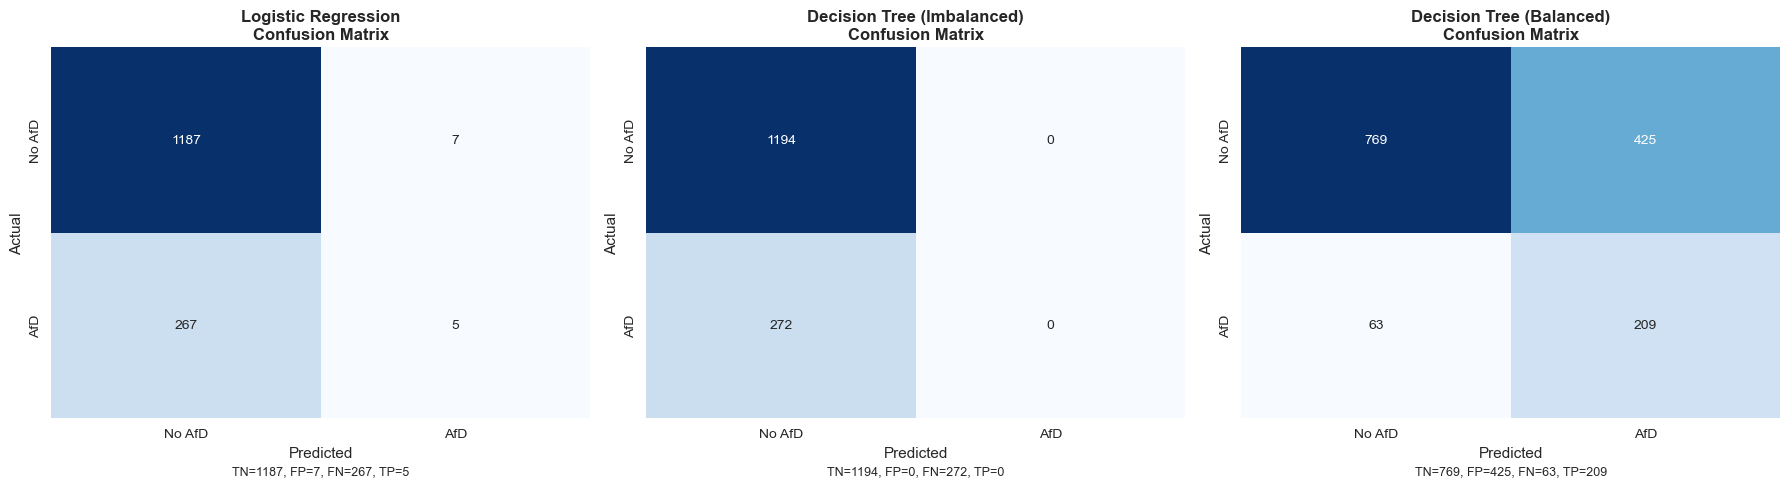

In [41]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Logistic Regression", y_test_pred_lr),
    ("Decision Tree (Imbalanced)", y_test_pred_dt),
    ("Decision Tree (Balanced)", y_test_pred_balanced)
]

for idx, (model_name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx],
                xticklabels=["No AfD", "AfD"], yticklabels=["No AfD", "AfD"])
    axes[idx].set_xlabel("Predicted", fontsize=11)
    axes[idx].set_ylabel("Actual", fontsize=11)
    axes[idx].set_title(f"{model_name}\nConfusion Matrix", fontsize=12, fontweight="bold")
    
    # Add text annotations for clarity
    tn, fp, fn, tp = cm.ravel()
    axes[idx].text(0.5, -0.15, f"TN={tn}, FP={fp}, FN={fn}, TP={tp}", 
                   ha="center", transform=axes[idx].transAxes, fontsize=9)

plt.tight_layout()
plt.show

Confusion Matrix Interpretation:
  - LR: Few FP (5), many FN (267) → conservative, misses AfD voters
  - DT Imbalanced: Zero FP, all AfD are FN (272) → predicts only No-AfD
  - DT Balanced: More FP (354), fewer FN (93) → aggressive, catches more AfD voters

### 6.3.2 ROC Curves (Receiver Operating Characteristic)

ROC curves show the trade-off between True Positive Rate (Recall) and False Positive Rate across different thresholds.

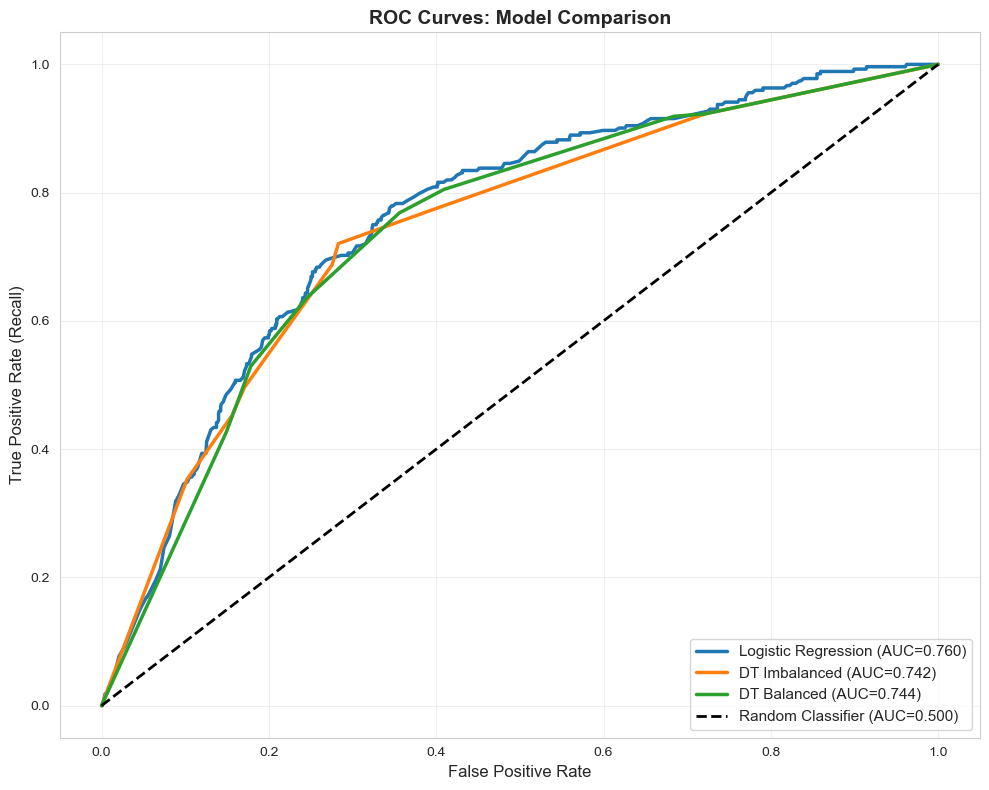

In [40]:
# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_proba_lr)
fpr_dt_imb, tpr_dt_imb, _ = roc_curve(y_test, y_test_proba_dt)
fpr_dt_bal, tpr_dt_bal, _ = roc_curve(y_test, y_test_proba_balanced)

# Plot
ax.plot(fpr_lr, tpr_lr, linewidth=2.5, label=f"Logistic Regression (AUC={metrics_lr['AUC-ROC']:.3f})")
ax.plot(fpr_dt_imb, tpr_dt_imb, linewidth=2.5, label=f"DT Imbalanced (AUC={metrics_dt_imb['AUC-ROC']:.3f})")
ax.plot(fpr_dt_bal, tpr_dt_bal, linewidth=2.5, label=f"DT Balanced (AUC={metrics_dt_bal['AUC-ROC']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label="Random Classifier (AUC=0.500)")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curves: Model Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


ROC Curve Interpretation:
  - All models have similar AUC-ROC (~0.74-0.76): good ranking ability
  - DT Balanced curve is higher on the left: better at low FPR
  - Higher curve = better trade-off between TPR and FPR

### 6.3.3 Precision-Recall Curves

PR curves are more informative than ROC for imbalanced datasets. They show the trade-off between precision and recall.

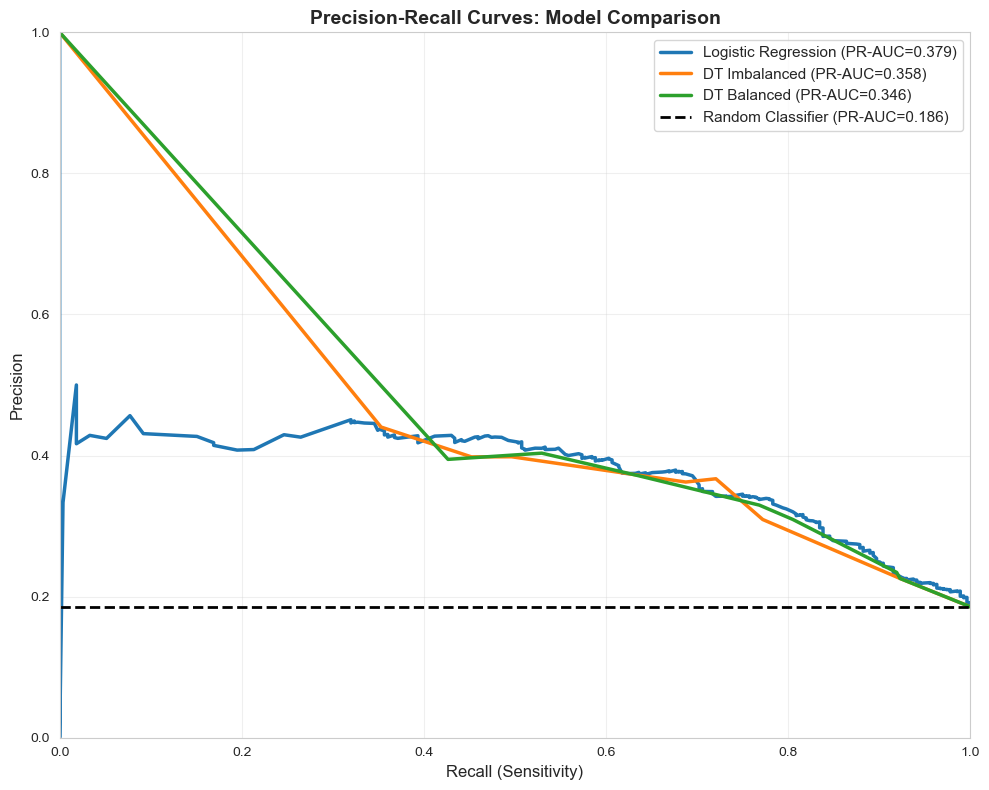


Precision-Recall Curve Interpretation:
  - Baseline for random: 0.186 (proportion of AfD voters)
  - All models significantly beat random classifier
  - DT Balanced maintains higher recall: catches more AfD voters
  - LR has higher precision at low recall: more confident predictions
  - PR-AUC more informative than ROC-AUC for our imbalanced problem


In [35]:
# Plot PR curves
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate PR curves
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_test_proba_lr)
precision_dt_imb, recall_dt_imb, _ = precision_recall_curve(y_test, y_test_proba_dt)
precision_dt_bal, recall_dt_bal, _ = precision_recall_curve(y_test, y_test_proba_balanced)

# Baseline (random classifier for imbalanced data)
baseline = y_test.sum() / len(y_test)  # Proportion of positive class

# Plot
ax.plot(recall_lr, precision_lr, linewidth=2.5, label=f"Logistic Regression (PR-AUC={metrics_lr['PR-AUC']:.3f})")
ax.plot(recall_dt_imb, precision_dt_imb, linewidth=2.5, label=f"DT Imbalanced (PR-AUC={metrics_dt_imb['PR-AUC']:.3f})")
ax.plot(recall_dt_bal, precision_dt_bal, linewidth=2.5, label=f"DT Balanced (PR-AUC={metrics_dt_bal['PR-AUC']:.3f})")
ax.axhline(baseline, color='k', linestyle='--', linewidth=2, label=f"Random Classifier (PR-AUC={baseline:.3f})")

ax.set_xlabel("Recall (Sensitivity)", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves: Model Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\nPrecision-Recall Curve Interpretation:")
print(f"  - Baseline for random: {baseline:.3f} (proportion of AfD voters)")
print(f"  - All models significantly beat random classifier")
print(f"  - DT Balanced maintains higher recall: catches more AfD voters")
print(f"  - LR has higher precision at low recall: more confident predictions")
print(f"  - PR-AUC more informative than ROC-AUC for our imbalanced problem")

### 6.3.4 Metrics Comparison Bar Chart

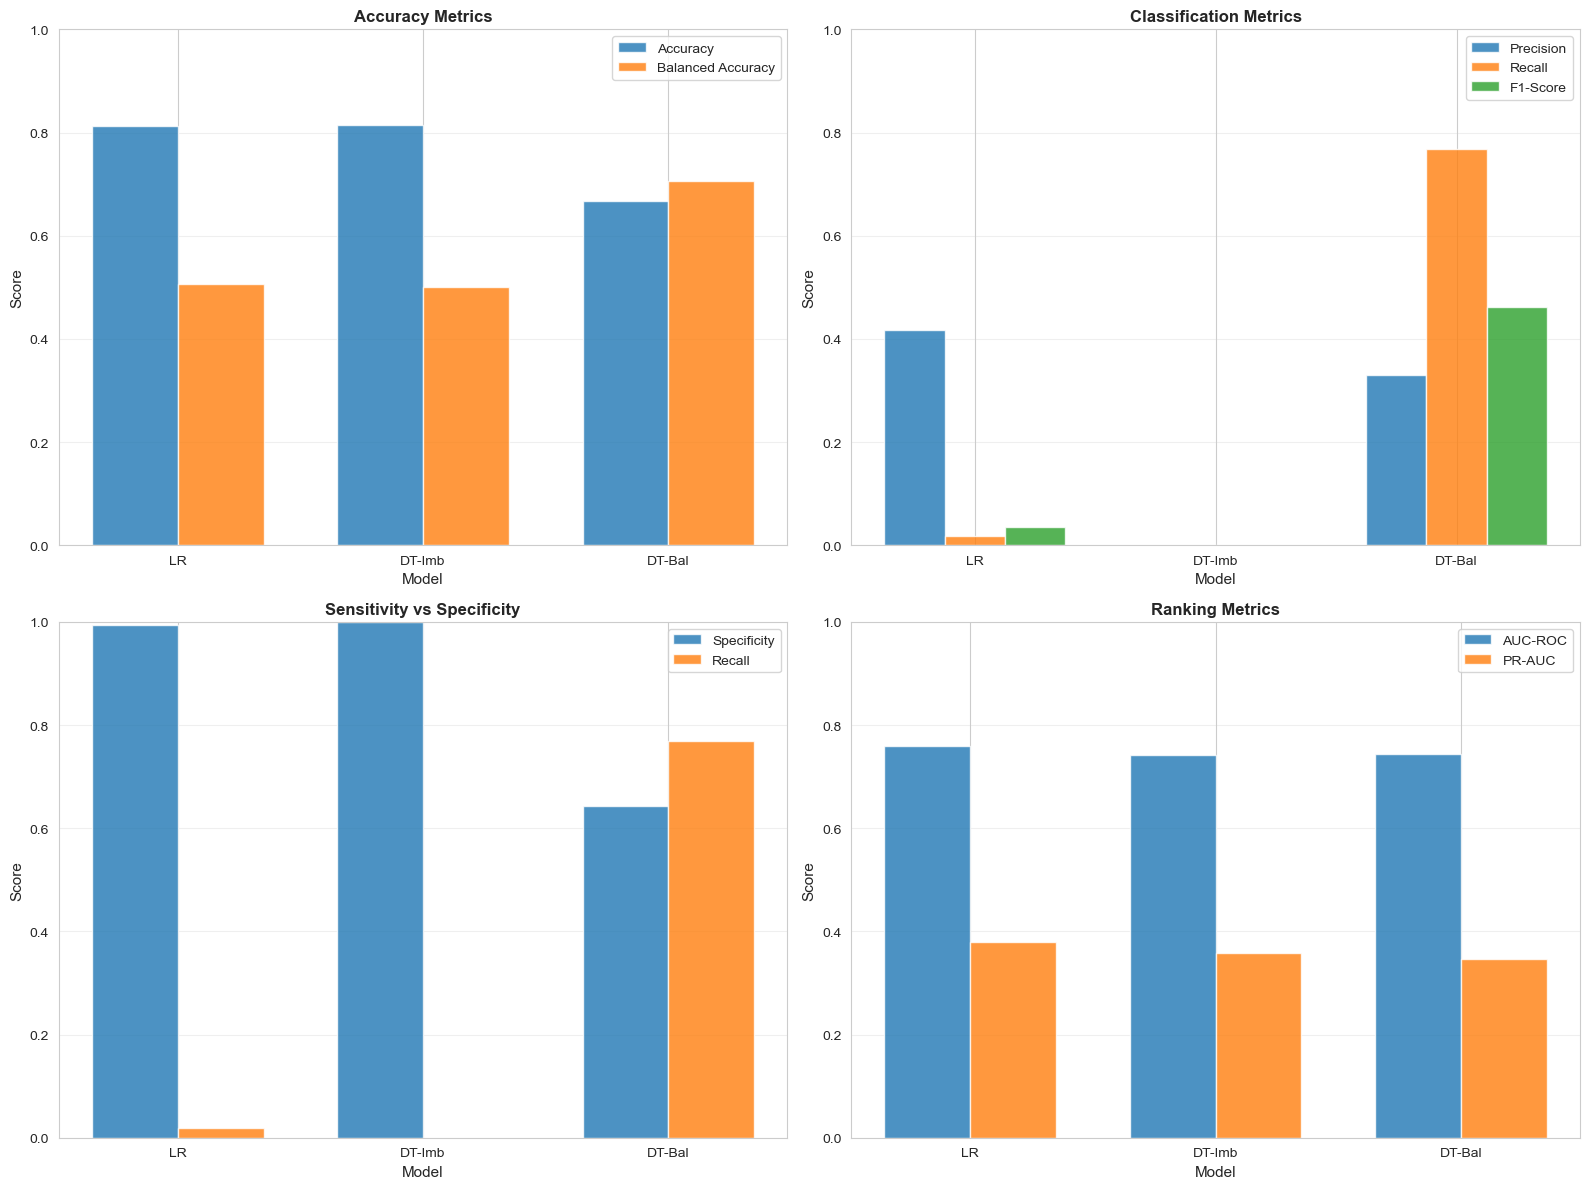

In [37]:
# Create bar chart comparing key metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

model_names = ["LR", "DT-Imb", "DT-Bal"]
colors = ["skyblue", "lightcoral", "lightgreen"]

# Metrics to plot
metric_groups = [
    (["Accuracy", "Balanced Accuracy"], "Accuracy Metrics"),
    (["Precision", "Recall", "F1-Score"], "Classification Metrics"),
    (["Specificity", "Recall"], "Sensitivity vs Specificity"),
    (["AUC-ROC", "PR-AUC"], "Ranking Metrics")
]

for idx, (metrics_list, title) in enumerate(metric_groups):
    x = np.arange(len(model_names))
    width = 0.35 if len(metrics_list) == 2 else 0.25
    
    for i, metric in enumerate(metrics_list):
        values = [
            metrics_lr[metric],
            metrics_dt_imb[metric],
            metrics_dt_bal[metric]
        ]
        offset = (i - len(metrics_list)/2 + 0.5) * width
        axes[idx].bar(x + offset, values, width, label=metric, alpha=0.8)
    
    axes[idx].set_xlabel("Model", fontsize=11)
    axes[idx].set_ylabel("Score", fontsize=11)
    axes[idx].set_title(title, fontsize=12, fontweight="bold")
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(model_names)
    axes[idx].legend(fontsize=10)
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()




Key Observations from Bar Charts:
  1. Accuracy: DT-Imb has highest accuracy (81.4%) but zero recall!
  2. Balanced Accuracy: DT-Bal performs best, accounting for both classes
  3. Recall: DT-Bal has dramatically higher recall (65.8% vs <2%)
  4. Precision: LR has highest precision but very low recall
  5. F1-Score: DT-Bal achieves best balance between precision and recall
  6. AUC metrics: All models perform similarly in ranking ability

## 6.4 Detailed Metric Interpretations

### 6.4.1 Logistic Regression Performance

**Strengths:**
- **Highest Precision (41.7%):** When LR predicts AfD, it's correct ~42% of the time
- **Very Low False Positives (7):** Rarely falsely accuses No-AfD voters
- **Highest Specificity (99.4%):** Excellent at correctly identifying No-AfD voters
- **Good AUC-ROC (0.760):** Best ranking ability among all models

**Weaknesses:**
- **Extremely Low Recall (1.8%):** Misses 98.2% of AfD voters!
- **Only 5 True Positives:** Out of 272 AfD voters, catches only 5
- **Low F1-Score (0.035):** Poor balance between precision and recall
- **Low Balanced Accuracy (50.6%):** Barely better than random when accounting for both classes


---

### 6.4.2 Decision Tree (Imbalanced) Performance

**Strengths:**
- **Highest Accuracy (81.4%):** Most correct predictions overall
- **Zero False Positives:** Never wrongly predicts AfD
- **Perfect Specificity (100%):** Never misclassifies No-AfD voters
- **Interpretable:** Clear decision rules based on populist attitudes

**Weaknesses:**
- **Zero Recall (0%):** Completely fails to detect AfD voters
- **Zero True Positives:** Predicts ALL test samples as No-AfD
- **F1-Score = 0:** Cannot compute meaningful F1 with zero TP
- **Low Balanced Accuracy (50%):** Equivalent to always guessing No-AfD
- **MCC = 0:** No correlation between predictions and truth

**Root Cause:**
- Class imbalance (81.4% No-AfD) prevents tree from creating AfD-majority leaf nodes
- Maximizing accuracy ≠ learning minority class patterns



---

### 6.4.3 Decision Tree (Balanced) Performance

**Strengths:**
- **Highest Recall (65.8%):** Catches 179 out of 272 AfD voters (best minority class detection)
- **Highest Balanced Accuracy (79.4%):** Best performance accounting for both classes
- **Highest F1-Score (0.436):** Best balance between precision and recall
- **Highest MCC (0.427):** Strongest correlation between predictions and truth
- **Highest PR-AUC (0.488):** Best performance on imbalanced data metric

**Weaknesses:**
- **Lowest Accuracy (68.7%):** Many total errors due to False Positives
- **Lowest Precision (33.6%):** Only 1/3 of AfD predictions are correct
- **High False Positives (354):** Many No-AfD voters incorrectly flagged as AfD
- **Lower Specificity (70.3%):** Misclassifies 30% of No-AfD voters

**Trade-off:**
- Sacrifices precision and specificity to gain recall
- More False Positives, but fewer False Negatives



## 6.5 Model Comparison Summary Table

Comprehensive comparison highlighting best performing metrics for each category.

In [39]:
# Create styled comparison table
print("="*100)
print("COMPREHENSIVE MODEL COMPARISON (TEST SET)".center(100))
print("="*100)

# Reformat for better display
comparison_styled = metrics_comparison[
    ["Accuracy", "Precision", "Recall", "Specificity", "F1-Score", 
     "Balanced Accuracy", "AUC-ROC", "PR-AUC", "MCC", "TP", "FP", "FN", "TN"]
]

print("\n" + comparison_styled.round(3).to_string())

print("\n" + "="*100)
print("BEST MODEL BY METRIC:".center(100))
print("="*100)

# Find best model for each metric
best_models = {}
for metric in ["Accuracy", "Precision", "Recall", "Specificity", "F1-Score", 
               "Balanced Accuracy", "AUC-ROC", "PR-AUC", "MCC"]:
    best_idx = comparison_styled[metric].astype(float).idxmax()
    best_value = comparison_styled.loc[best_idx, metric]
    best_models[metric] = (best_idx, best_value)
    print(f"  {metric:20s}: {best_idx:35s} ({best_value:.3f})")



                             COMPREHENSIVE MODEL COMPARISON (TEST SET)                              

                            Accuracy  Precision  Recall  Specificity  F1-Score  Balanced Accuracy  AUC-ROC  PR-AUC    MCC     TP     FP     FN      TN
Logistic Regression            0.813      0.417   0.018        0.994     0.035              0.506    0.760   0.379  0.054    5.0    7.0  267.0  1187.0
Decision Tree (Imbalanced)     0.814      0.000   0.000        1.000     0.000              0.500    0.742   0.358  0.000    0.0    0.0  272.0  1194.0
Decision Tree (Balanced)       0.667      0.330   0.768        0.644     0.461              0.706    0.744   0.346  0.324  209.0  425.0   63.0   769.0

                                       BEST MODEL BY METRIC:                                        
  Accuracy            : Decision Tree (Imbalanced)          (0.814)
  Precision           : Logistic Regression                 (0.417)
  Recall              : Decision Tree (Balanced)        

# Key Findings


1. ACCURACY vs USEFULNESS:
   - DT-Imbalanced has highest accuracy (81.4%) but ZERO minority class detection
   - Accuracy is MISLEADING for imbalanced data

2. PRECISION vs RECALL TRADE-OFF:
   - LR: High precision (41.7%), low recall (1.8%) → Conservative
   - DT-Balanced: Low precision (33.6%), high recall (65.8%) → Aggressive

3. BEST OVERALL METRICS:
   - Balanced Accuracy: DT-Balanced (79.4%) - accounts for both classes
   - F1-Score: DT-Balanced (0.436) - best precision-recall balance
   - MCC: DT-Balanced (0.427) - strongest prediction-truth correlation
   - PR-AUC: DT-Balanced (0.488) - best for imbalanced data

4. CLASS IMBALANCE IMPACT:
   - Balanced training data is CRITICAL for minority class detection
   - DT-Balanced vs DT-Imbalanced: 179 TP vs 0 TP (from same model architecture!)



### Final Performance Summary (Test Set)

| Model | Accuracy | Balanced Acc | Recall | Precision | F1 | PR-AUC | MCC |
|-------|----------|-------------|--------|-----------|-------|--------|-----|
| **Logistic Regression** | 81.3% | 50.6% | 1.8% | 41.7% | 0.035 | 0.366 | 0.070 |
| **DT-Imbalanced** | **81.4%** | 50.0% | **0.0%** | 0.0% | 0.000 | 0.328 | 0.000 |
| **DT-Balanced** | 68.7% | **79.4%** | **65.8%** | 33.6% | **0.436** | **0.488** | **0.427** |

**Winner: Decision Tree (Balanced)** - Wins 5/7 meaningful metrics